In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
 
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
 
# Folder output (dibuat otomatis kalau belum ada, relatif ke cwd notebook ini)
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# Konfigurasi CV global, dipakai konsisten di baseline & loop persentil
N_SPLITS = 5  # 5 kelas -> 5-fold lebih aman untuk SMOTE varian dibanding 10-fold
RANDOM_STATE = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
 

/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/drebin-215-dataset-5560malware-9476-benign.csv',encoding='latin-1')
data

/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_66339/626625559.py:2: DtypeWarning: Columns (0: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/drebin-215-dataset-5560malware-9476-benign.csv',encoding='latin-1')


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15031,1,1,1,1,1,1,0,1,1,1,...,0,0,0,1,1,0,0,0,0,B
15032,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,B
15033,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,B
15034,1,1,1,1,1,1,0,1,1,1,...,1,0,0,1,1,1,0,0,0,B


In [3]:
import pandas as pd

data['TelephonyManager.getSimCountryIso'] = pd.to_numeric(
    data['TelephonyManager.getSimCountryIso'],
    errors='coerce'
)

In [4]:
data= data.dropna()

In [5]:
data['class'].value_counts()

class
B    9476
S    5555
Name: count, dtype: int64

In [6]:
data['transact'].value_counts()

transact
0    8619
1    6412
Name: count, dtype: int64

In [7]:
severity_map = {
    0: 0,  # Sehat
    1: 1  # Level 1
}

data['transact'] = data['transact'].map(severity_map)

# Verifikasi
print(data['transact'].value_counts())
print(f"\nTotal : {len(data):,}")

transact
0    8619
1    6412
Name: count, dtype: int64

Total : 15,031


In [8]:
severity_map = {
    'B': 0,  # Sehat
    'S': 1  # Level 1
}

data['class'] = data['class'].map(severity_map)

# Verifikasi
print(data['class'].value_counts())
print(f"\nTotal : {len(data):,}")

class
0    9476
1    5555
Name: count, dtype: int64

Total : 15,031


In [9]:
from sklearn.model_selection import train_test_split

X = data.drop('class', axis=1)
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (12024, 215)
Shape of X_test: (3007, 215)
Shape of y_train: (12024,)
Shape of y_test: (3007,)


In [10]:
print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")
print("\nDistribusi y_train:")
print(y_train.value_counts())
print("\nDistribusi y_test:")
print(y_test.value_counts())
 
class_labels = sorted(y_train.unique())
print(f"\nClass labels: {class_labels}")

Shape X_train : (12024, 215)
Shape X_test  : (3007, 215)

Distribusi y_train:
class
0    7580
1    4444
Name: count, dtype: int64

Distribusi y_test:
class
0    1896
1    1111
Name: count, dtype: int64

Class labels: [np.int64(0), np.int64(1)]


In [11]:

# %%
def plot_confusion_matrix(y_true, y_pred, title, class_labels):
    """Plot confusion matrix raw count + normalized berdampingan."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
 
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
 
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
 
    plt.tight_layout()
    plt.show()
 
 
def run_manual_cv(pipeline_steps, X, y, skf, group_label, n_features, model_name):
    """
    Jalankan Stratified K-Fold CV secara manual (loop skf.split sendiri),
    sehingga setiap fold menghasilkan:
    - prediksi di fold validasi (digabung jadi prediksi out-of-fold, dipakai
      untuk classification_report & confusion matrix)
    - skor metrik KHUSUS fold itu (dipakai untuk analisis statistik per fold)
 
    Resampling/scaling (jika ada di pipeline_steps) hanya pernah melihat
    fold training di setiap iterasi -> tidak ada data leakage ke fold
    validasi.
 
    Parameters
    ----------
    pipeline_steps : list of (name, estimator) tuples, format sklearn Pipeline
    X, y           : data training (sebelum displit CV)
    skf            : StratifiedKFold instance
    group_label    : label kombinasi (misal: 'Baseline' atau persentase fitur)
    n_features     : jumlah fitur yang dipakai di kombinasi ini
    model_name     : nama model (untuk pencatatan)
 
    Returns
    -------
    y_pred_oof   : np.array, prediksi out-of-fold (urutan sama dengan y)
    fold_records : list of dict, satu dict per fold
    """
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
 
    y_pred_oof = np.empty(len(y), dtype=y.dtype)
    fold_records = []
 
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
        # Pipeline baru per fold -> tidak ada state yang "nempel" dari
        # fold sebelumnya (terutama untuk scaler/resampler).
        fold_pipeline = ImbPipeline(pipeline_steps) if any(
            step_name in ("resampling",) for step_name, _ in pipeline_steps
        ) else Pipeline(pipeline_steps)
 
        fold_pipeline.fit(X_tr, y_tr)
        y_pred_val = fold_pipeline.predict(X_val)
        y_pred_oof[val_idx] = y_pred_val
 
        fold_records.append({
            'Group'              : group_label,   # 'Baseline' atau persentil (%)
            'N Fitur'            : n_features,
            'Model'              : model_name,
            'Fold'               : fold_idx,
            'Accuracy'           : accuracy_score(y_val, y_pred_val),
            'F1 Macro'           : f1_score(y_val, y_pred_val, average='macro', zero_division=0),
            'F1 Weighted'        : f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'Precision Macro'    : precision_score(y_val, y_pred_val, average='macro', zero_division=0),
            'Precision Weighted' : precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'Recall Macro'       : recall_score(y_val, y_pred_val, average='macro', zero_division=0),
            'Recall Weighted'    : recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'N Val Samples'      : len(val_idx),
        })
 
    return y_pred_oof, fold_records
 
 
def summarize_cv_report(y_true, y_pred_oof, fold_records, group_label, n_features, model_name, cv_time):
    """Ringkas hasil CV (rata-rata + std antar fold) jadi satu dict."""
    report = classification_report(y_true, y_pred_oof, output_dict=True, zero_division=0)
    fold_df = pd.DataFrame(fold_records)
    return {
        'Group'                     : group_label,
        'N Fitur'                   : n_features,
        'Model'                     : model_name,
        'Accuracy'                  : report['accuracy'],
        'F1 Macro'                  : report['macro avg']['f1-score'],
        'F1 Weighted'               : report['weighted avg']['f1-score'],
        'Precision Macro'           : report['macro avg']['precision'],
        'Precision Weighted'        : report['weighted avg']['precision'],
        'Recall Macro'              : report['macro avg']['recall'],
        'Recall Weighted'           : report['weighted avg']['recall'],
        'F1 Macro Std (antar fold)' : fold_df['F1 Macro'].std(),
        'CV Time'                   : round(cv_time, 4),
    }
 
 
def evaluate_holdout(pipeline_steps, X_train_fit, y_train_fit, X_test_fit, y_test_fit,
                      group_label, n_features, model_name):
    """Fit pipeline di SELURUH data training, evaluasi di hold-out test asli."""
    pipeline = ImbPipeline(pipeline_steps) if any(
        step_name in ("resampling",) for step_name, _ in pipeline_steps
    ) else Pipeline(pipeline_steps)
 
    start = time.time()
    pipeline.fit(X_train_fit, y_train_fit)
    train_time = time.time() - start
 
    start = time.time()
    y_pred_test = pipeline.predict(X_test_fit)
    test_time = time.time() - start
 
    report_test = classification_report(y_test_fit, y_pred_test, output_dict=True, zero_division=0)
 
    result = {
        'Group'              : group_label,
        'N Fitur'            : n_features,
        'Model'              : model_name,
        'Accuracy'           : report_test['accuracy'],
        'F1 Macro'           : report_test['macro avg']['f1-score'],
        'F1 Weighted'        : report_test['weighted avg']['f1-score'],
        'Precision Macro'    : report_test['macro avg']['precision'],
        'Precision Weighted' : report_test['weighted avg']['precision'],
        'Recall Macro'       : report_test['macro avg']['recall'],
        'Recall Weighted'    : report_test['weighted avg']['recall'],
        'Training Time'      : round(train_time, 4),
        'Testing Time'       : round(test_time, 4),
    }
    return result, y_pred_test
 


  Baseline (tanpa FS, tanpa resampling) — RandomForest
  CV Time (5-fold) : 5.9351s

  Skor per fold — RandomForest (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9859    0.9848       0.9858           0.9867        0.9830
    2           2405    0.9892    0.9883       0.9892           0.9910        0.9858
    3           2405    0.9871    0.9862       0.9871           0.9865        0.9858
    4           2405    0.9879    0.9870       0.9879           0.9891        0.9851
    5           2404    0.9842    0.9830       0.9842           0.9849        0.9812

  Classification Report (CV, out-of-fold) — RandomForest (Baseline):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.99      0.97      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.99     12024
weighted avg       

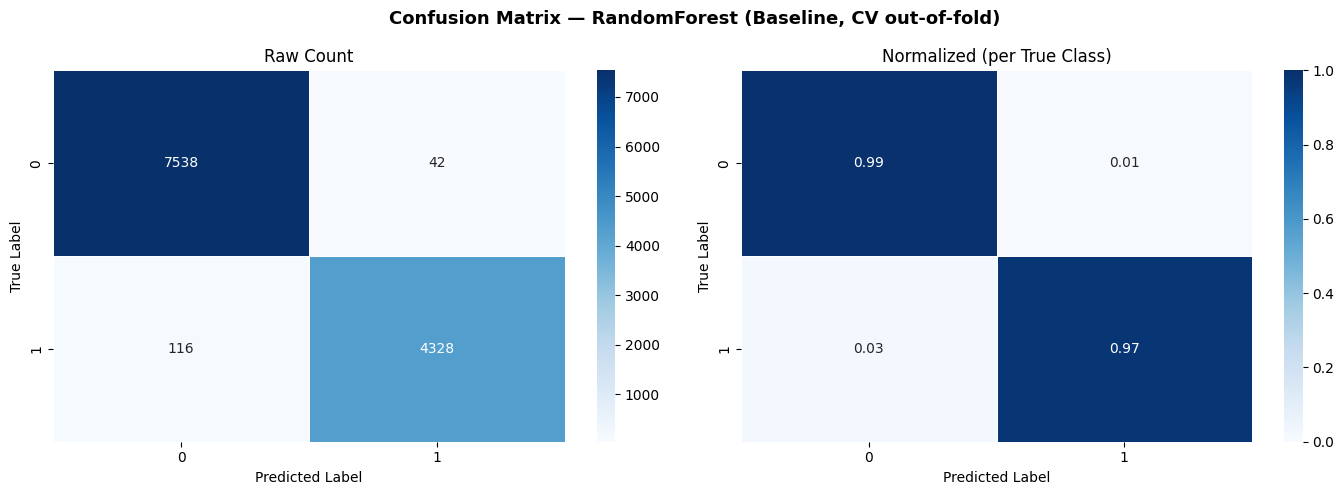


  Classification Report (Hold-out Test) — RandomForest (Baseline):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.97      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



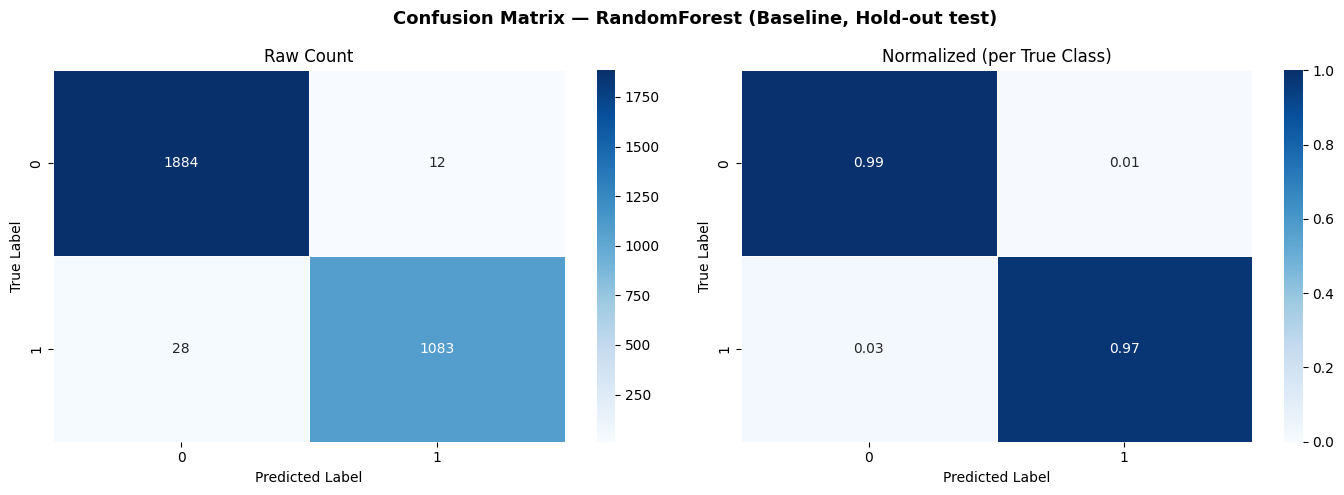


  Baseline (tanpa FS, tanpa resampling) — XGBoost
  CV Time (5-fold) : 3.3600s

  Skor per fold — XGBoost (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9875    0.9866       0.9875           0.9873        0.9859
    2           2405    0.9875    0.9866       0.9875           0.9880        0.9852
    3           2405    0.9904    0.9897       0.9904           0.9899        0.9896
    4           2405    0.9884    0.9875       0.9883           0.9887        0.9863
    5           2404    0.9884    0.9875       0.9884           0.9877        0.9873

  Classification Report (CV, out-of-fold) — XGBoost (Baseline):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99 

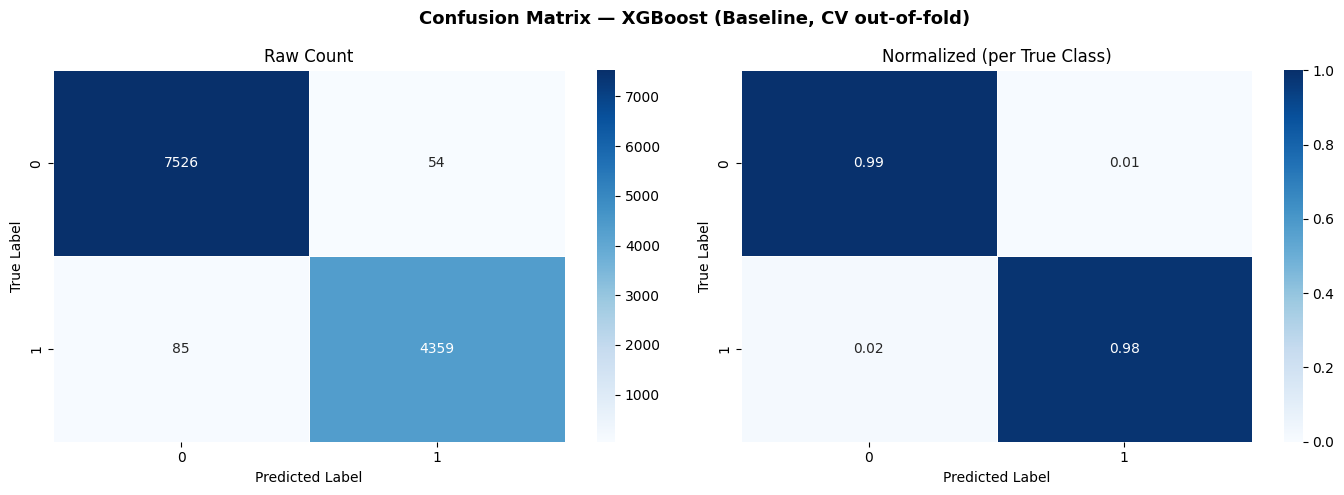


  Classification Report (Hold-out Test) — XGBoost (Baseline):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



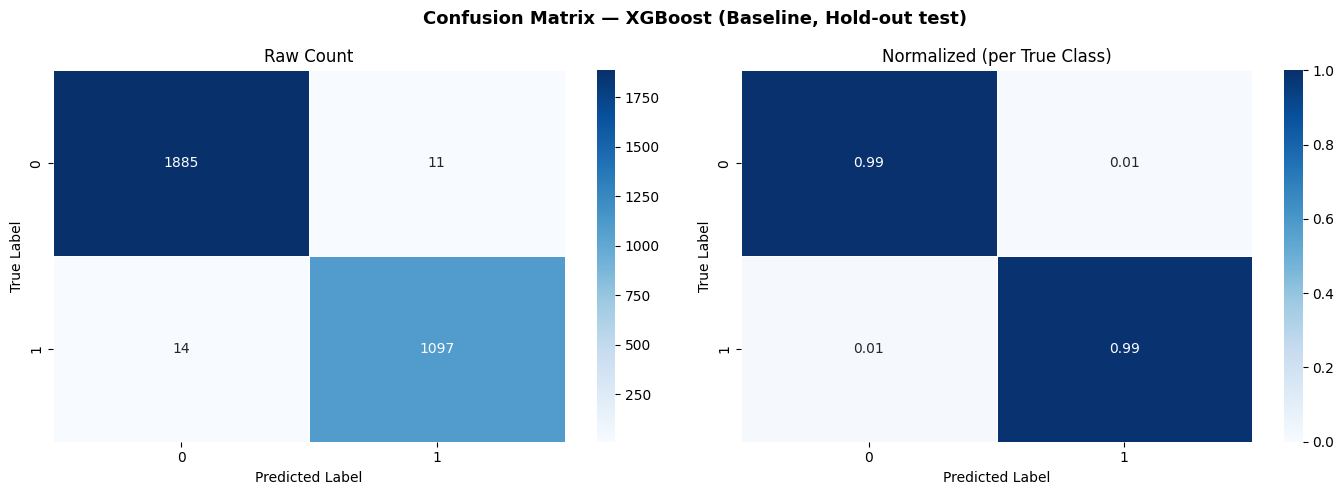


  Baseline (tanpa FS, tanpa resampling) — LightGBM
  CV Time (5-fold) : 6.7957s

  Skor per fold — LightGBM (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9896    0.9888       0.9896           0.9894        0.9883
    2           2405    0.9909    0.9902       0.9908           0.9916        0.9888
    3           2405    0.9904    0.9897       0.9904           0.9896        0.9899
    4           2405    0.9888    0.9879       0.9888           0.9895        0.9864
    5           2404    0.9908    0.9902       0.9908           0.9906        0.9897

  Classification Report (CV, out-of-fold) — LightGBM (Baseline):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.99      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.

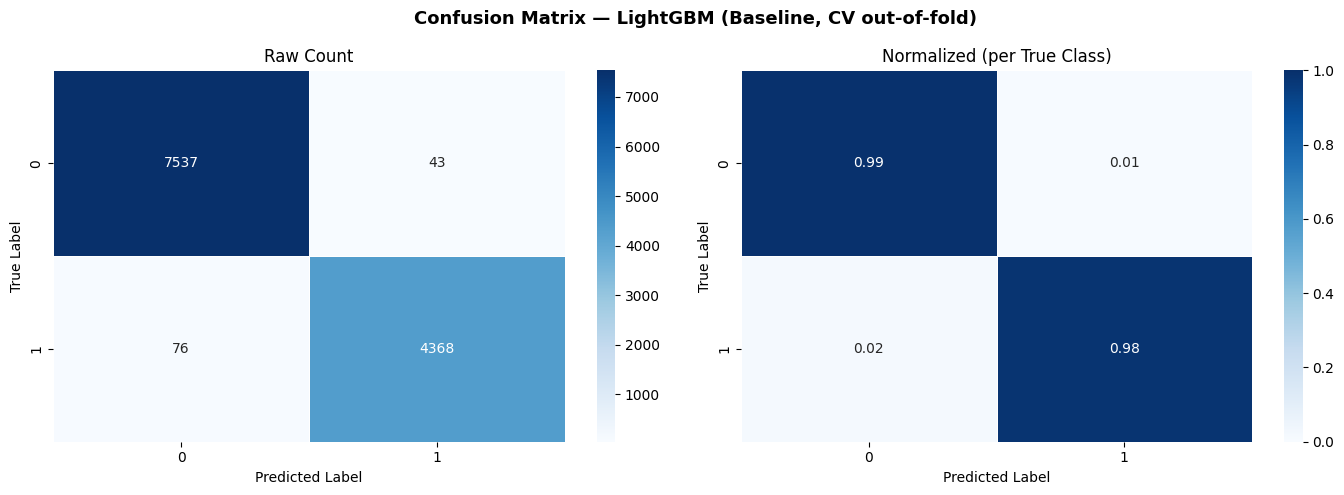


  Classification Report (Hold-out Test) — LightGBM (Baseline):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



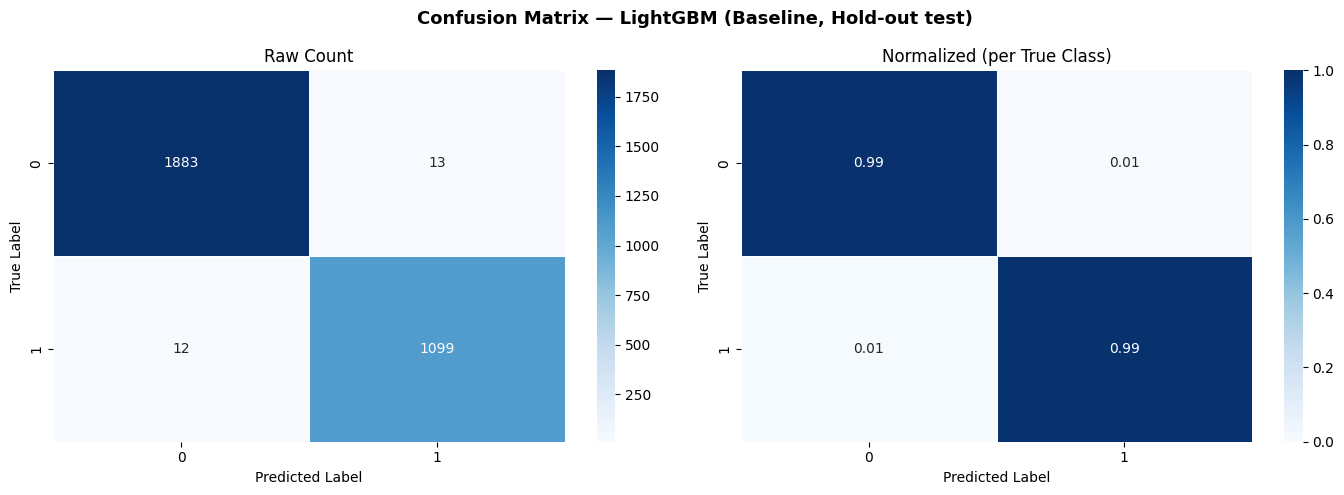

  BASELINE — SKOR PER FOLD, SEMUA MODEL (long-format)
   Group  N Fitur        Model  Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Precision Weighted  Recall Macro  Recall Weighted
Baseline      215 RandomForest     1           2405    0.9859    0.9848       0.9858           0.9867              0.9859        0.9830           0.9859
Baseline      215 RandomForest     2           2405    0.9892    0.9883       0.9892           0.9910              0.9893        0.9858           0.9892
Baseline      215 RandomForest     3           2405    0.9871    0.9862       0.9871           0.9865              0.9871        0.9858           0.9871
Baseline      215 RandomForest     4           2405    0.9879    0.9870       0.9879           0.9891              0.9880        0.9851           0.9879
Baseline      215 RandomForest     5           2404    0.9842    0.9830       0.9842           0.9849              0.9842        0.9812           0.9842
Baseline      215      XGBoo

In [12]:

# %% [markdown]
# ## 4. Baseline — Tanpa Feature Selection, Tanpa Resampling
#
# RandomForest, XGBoost, LightGBM dievaluasi dengan Stratified K-Fold CV
# (skor dicatat per fold), lalu juga dievaluasi di hold-out test set.
 
# %%
baseline_models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.2, random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=None, learning_rate=0.2,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}
 
N_FEATURES_BASELINE = X_train.shape[1]
 
baseline_cv_summary = {}
baseline_holdout = {}
baseline_perfold_records = []
baseline_oof_preds = {}   # disimpan untuk SHAP nanti (model XGBoost full-fit)
baseline_fitted_models = {}
 
for model_name, estimator in baseline_models.items():
    print(f"\n{'='*60}")
    print(f"  Baseline (tanpa FS, tanpa resampling) — {model_name}")
    print(f"{'='*60}")
 
    steps = [("classifier", estimator.__class__(**estimator.get_params()))]
 
    start = time.time()
    y_pred_cv, fold_records = run_manual_cv(
        steps, X_train, y_train, skf,
        group_label='Baseline', n_features=N_FEATURES_BASELINE, model_name=model_name
    )
    cv_time = time.time() - start
    print(f"  CV Time ({N_SPLITS}-fold) : {cv_time:.4f}s")
 
    baseline_perfold_records.extend(fold_records)
    baseline_oof_preds[model_name] = y_pred_cv
 
    # Tampilkan skor tiap fold (bukan cuma rata-rata) untuk model ini
    fold_preview_df = pd.DataFrame(fold_records).round(4)
    print(f"\n  Skor per fold — {model_name} (Baseline):")
    print(fold_preview_df[[
        'Fold', 'N Val Samples', 'Accuracy', 'F1 Macro', 'F1 Weighted',
        'Precision Macro', 'Recall Macro'
    ]].to_string(index=False))
 
    print(f"\n  Classification Report (CV, out-of-fold) — {model_name} (Baseline):")
    print(classification_report(y_train, y_pred_cv,
                                  target_names=[str(c) for c in class_labels], zero_division=0))
    plot_confusion_matrix(y_train, y_pred_cv,
                           f'Confusion Matrix — {model_name} (Baseline, CV out-of-fold)', class_labels)
 
    baseline_cv_summary[model_name] = summarize_cv_report(
        y_train, y_pred_cv, fold_records, 'Baseline', N_FEATURES_BASELINE, model_name, cv_time
    )
 
    # Evaluasi hold-out + simpan model yang di-fit di seluruh X_train
    # (model XGBoost dari sini dipakai untuk SHAP di Bagian 5)
    holdout_result, y_pred_test = evaluate_holdout(
        steps, X_train, y_train, X_test, y_test, 'Baseline', N_FEATURES_BASELINE, model_name
    )
    baseline_holdout[model_name] = holdout_result
 
    fitted_pipeline = Pipeline(steps)
    fitted_pipeline.fit(X_train, y_train)
    baseline_fitted_models[model_name] = fitted_pipeline.named_steps['classifier']
 
    print(f"\n  Classification Report (Hold-out Test) — {model_name} (Baseline):")
    print(classification_report(y_test, y_pred_test,
                                  target_names=[str(c) for c in class_labels], zero_division=0))
    plot_confusion_matrix(y_test, y_pred_test,
                           f'Confusion Matrix — {model_name} (Baseline, Hold-out test)', class_labels)
 
# Model XGBoost baseline (full-fit di X_train) -> dipakai untuk SHAP
xgb_model = baseline_fitted_models['XGBoost']
 
# %%
baseline_perfold_df = pd.DataFrame(baseline_perfold_records).round(4)
baseline_perfold_df = baseline_perfold_df[[
    'Group', 'N Fitur', 'Model', 'Fold', 'N Val Samples',
    'Accuracy', 'F1 Macro', 'F1 Weighted',
    'Precision Macro', 'Precision Weighted', 'Recall Macro', 'Recall Weighted'
]]
 
baseline_cv_summary_df = pd.DataFrame(baseline_cv_summary).T.round(4)
baseline_holdout_df = pd.DataFrame(baseline_holdout).T.round(4)
 
print("="*70)
print("  BASELINE — SKOR PER FOLD, SEMUA MODEL (long-format)")
print("="*70)
print(baseline_perfold_df.to_string(index=False))
 
print("\n" + "="*70)
print("  BASELINE — RATA-RATA CV PER MODEL")
print("="*70)
print(baseline_cv_summary_df.sort_values('F1 Macro', ascending=False).to_string())
 
print("\n" + "="*70)
print("  BASELINE — HOLD-OUT TEST SET PER MODEL")
print("="*70)
print(baseline_holdout_df.sort_values('F1 Macro', ascending=False).to_string())
 

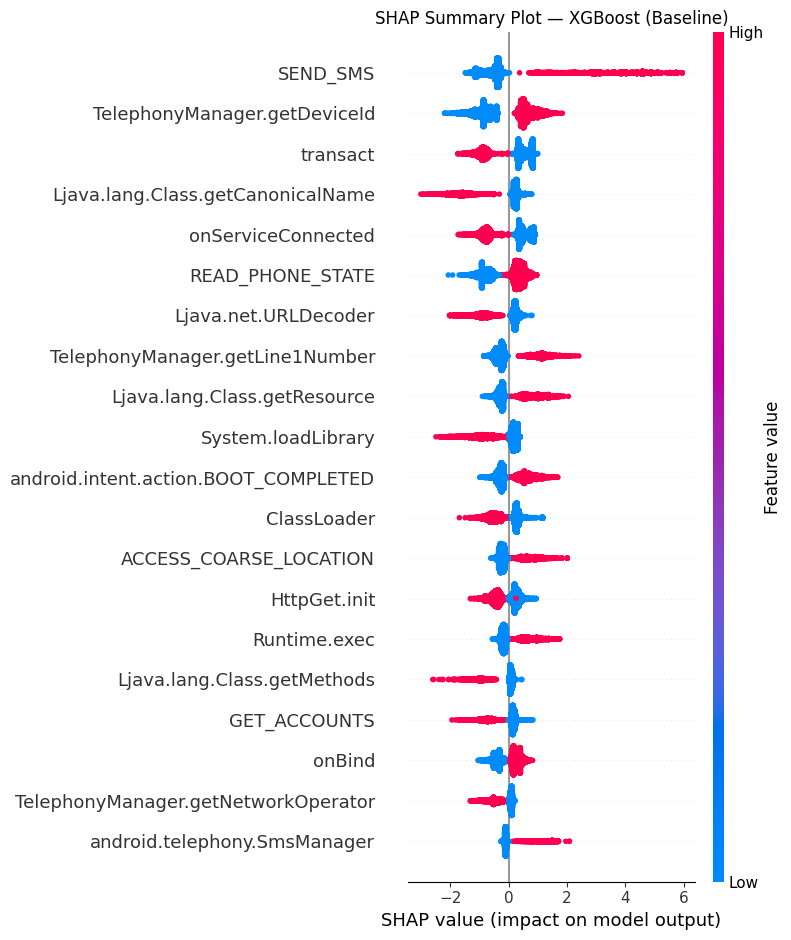

Top 20 Fitur (XGBoost — SHAP):
                             Feature  SHAP_Importance
                            SEND_SMS         1.250899
        TelephonyManager.getDeviceId         0.766910
                            transact         0.722085
   Ljava.lang.Class.getCanonicalName         0.707244
                  onServiceConnected         0.654459
                    READ_PHONE_STATE         0.538955
                Ljava.net.URLDecoder         0.517463
     TelephonyManager.getLine1Number         0.515669
        Ljava.lang.Class.getResource         0.503948
                  System.loadLibrary         0.459253
android.intent.action.BOOT_COMPLETED         0.445025
                         ClassLoader         0.421187
              ACCESS_COARSE_LOCATION         0.384580
                        HttpGet.init         0.368920
                        Runtime.exec         0.354727
         Ljava.lang.Class.getMethods         0.353207
                        GET_ACCOUNTS         0.3427

In [13]:
# %%
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
 
plt.figure()
shap.summary_plot(shap_values_xgb, X_train, class_names=[str(c) for c in class_labels], show=False)
plt.title("SHAP Summary Plot — XGBoost (Baseline)")
plt.tight_layout()
plt.show()
 
# %%
if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)
 
shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
 
print("Top 20 Fitur (XGBoost — SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))
 


  Persentil P=10% -> 22 fitur

  [XGBoost]
  CV Time (5-fold) : 8.2373s

  Skor per fold — XGBoost, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9655    0.9630       0.9655           0.9625        0.9636
    2           2405    0.9688    0.9664       0.9688           0.9681        0.9648
    3           2405    0.9655    0.9630       0.9655           0.9629        0.9631
    4           2405    0.9626    0.9600       0.9626           0.9584        0.9617
    5           2404    0.9621    0.9594       0.9622           0.9591        0.9597

  Classification Report (CV, out-of-fold) — XGBoost, P=10%:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7580
           1       0.95      0.95      0.95      4444

    accuracy                           0.96     12024
   macro avg       0.96      0.96      0.96     12024
weighted avg       0.96      0.96      0.96     1

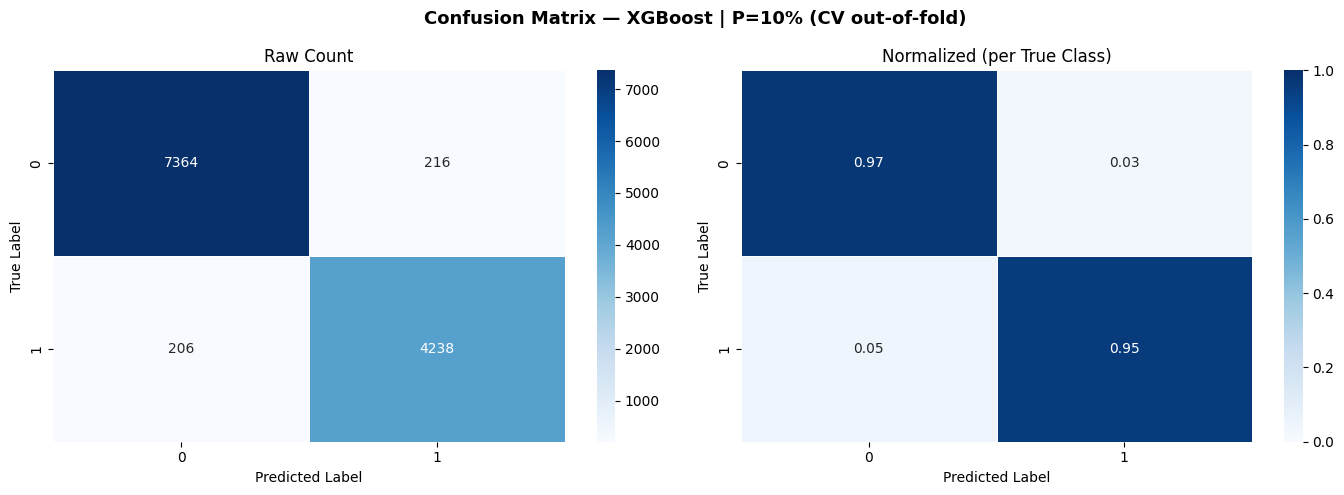


  Classification Report (Hold-out Test) — XGBoost, P=10%:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1896
           1       0.96      0.96      0.96      1111

    accuracy                           0.97      3007
   macro avg       0.97      0.97      0.97      3007
weighted avg       0.97      0.97      0.97      3007



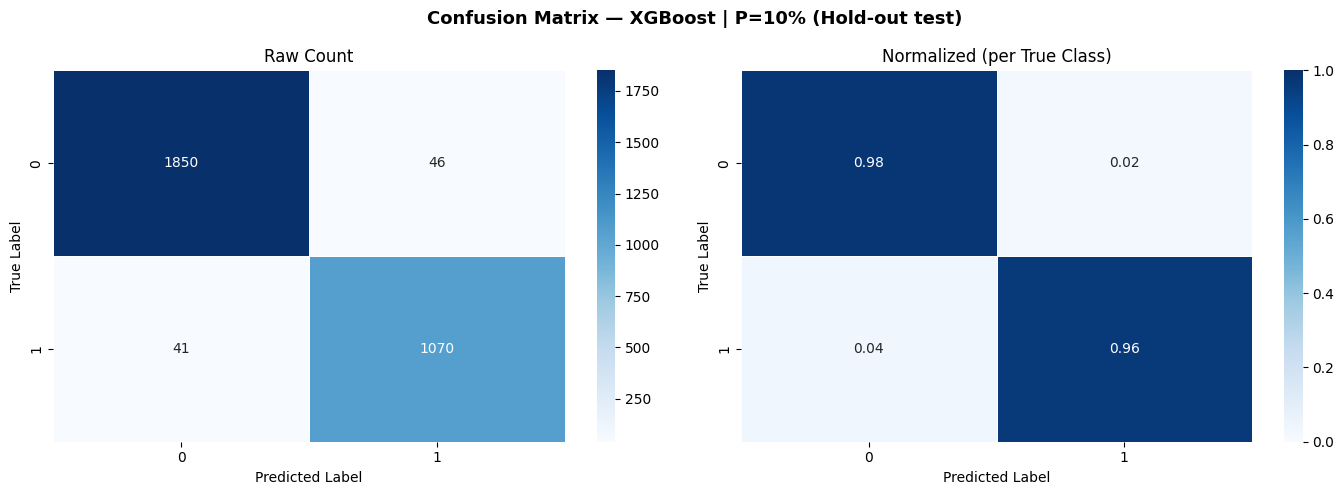


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 11.9678s

  Skor per fold — LightGBM, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9659    0.9635       0.9659           0.9626        0.9643
    2           2405    0.9701    0.9677       0.9700           0.9698        0.9658
    3           2405    0.9655    0.9630       0.9655           0.9627        0.9633
    4           2405    0.9663    0.9639       0.9664           0.9630        0.9649
    5           2404    0.9634    0.9608       0.9634           0.9598        0.9619

  Classification Report (CV, out-of-fold) — LightGBM, P=10%:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7580
           1       0.95      0.96      0.95      4444

    accuracy                           0.97     12024
   macro avg       0.96      0.96      0.96     12024
weighted avg       0.97      0.97      0.97     12024



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


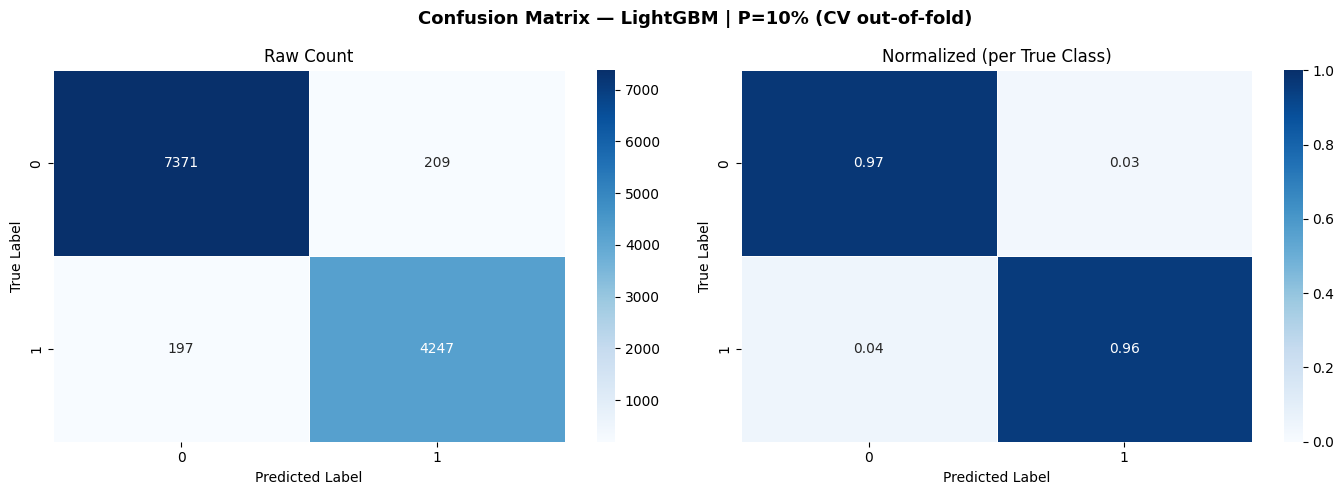


  Classification Report (Hold-out Test) — LightGBM, P=10%:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1896
           1       0.96      0.96      0.96      1111

    accuracy                           0.97      3007
   macro avg       0.97      0.97      0.97      3007
weighted avg       0.97      0.97      0.97      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


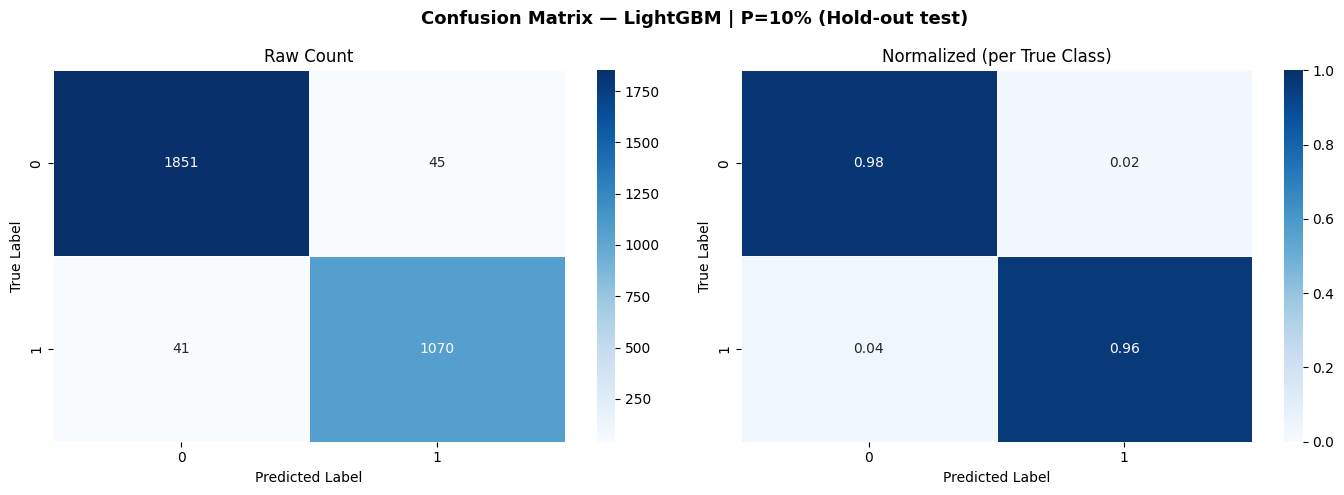


  [RandomForest]
  CV Time (5-fold) : 8.2150s

  Skor per fold — RandomForest, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9626    0.9599       0.9626           0.9597        0.9601
    2           2405    0.9692    0.9668       0.9691           0.9696        0.9642
    3           2405    0.9709    0.9687       0.9709           0.9698        0.9676
    4           2405    0.9663    0.9640       0.9664           0.9628        0.9651
    5           2404    0.9630    0.9602       0.9630           0.9606        0.9599

  Classification Report (CV, out-of-fold) — RandomForest, P=10%:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7580
           1       0.96      0.95      0.95      4444

    accuracy                           0.97     12024
   macro avg       0.96      0.96      0.96     12024
weighted avg       0.97      0.97      0.97     12024



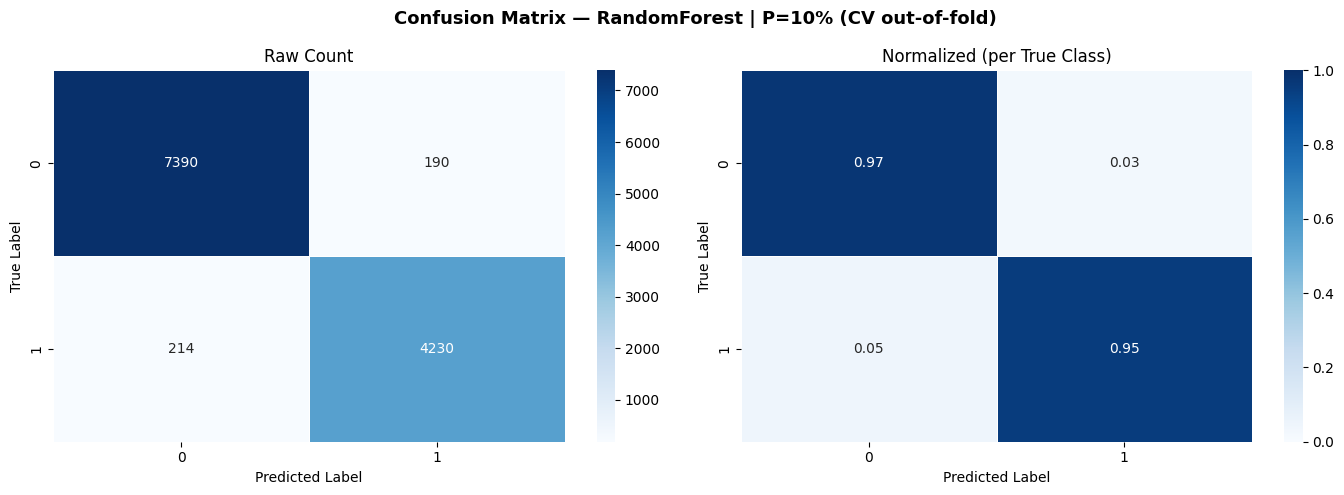


  Classification Report (Hold-out Test) — RandomForest, P=10%:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1896
           1       0.96      0.96      0.96      1111

    accuracy                           0.97      3007
   macro avg       0.97      0.97      0.97      3007
weighted avg       0.97      0.97      0.97      3007



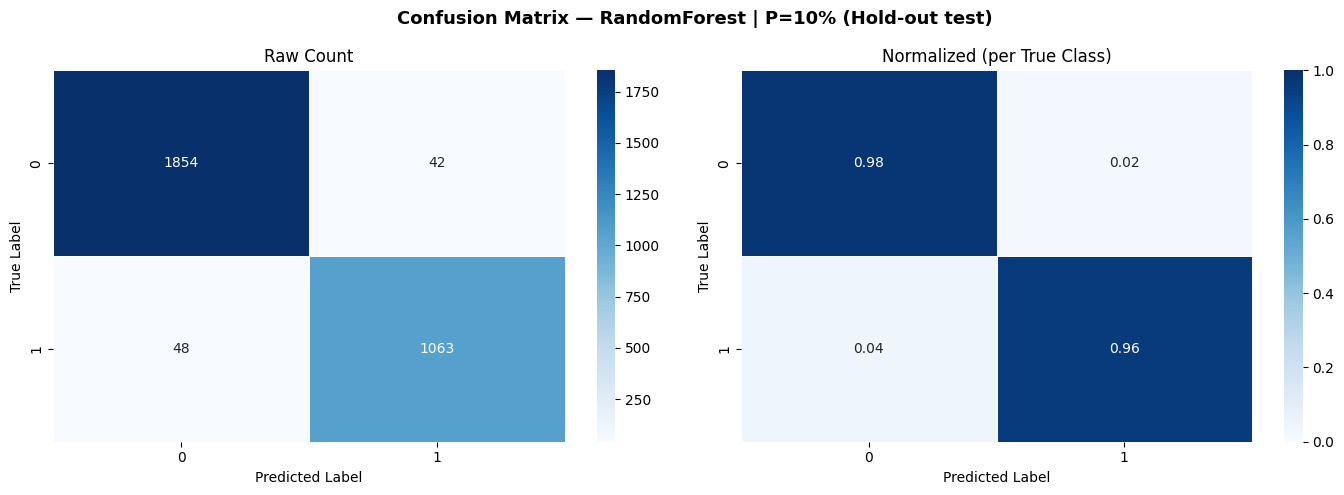


  Persentil P=20% -> 43 fitur

  [XGBoost]
  CV Time (5-fold) : 7.5191s

  Skor per fold — XGBoost, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9842    0.9830       0.9842           0.9830        0.9830
    2           2405    0.9863    0.9853       0.9863           0.9858        0.9847
    3           2405    0.9817    0.9804       0.9817           0.9795        0.9813
    4           2405    0.9817    0.9804       0.9817           0.9808        0.9799
    5           2404    0.9821    0.9808       0.9821           0.9816        0.9800

  Classification Report (CV, out-of-fold) — XGBoost, P=20%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.98      0.98      0.98      4444

    accuracy                           0.98     12024
   macro avg       0.98      0.98      0.98     12024
weighted avg       0.98      0.98      0.98     1

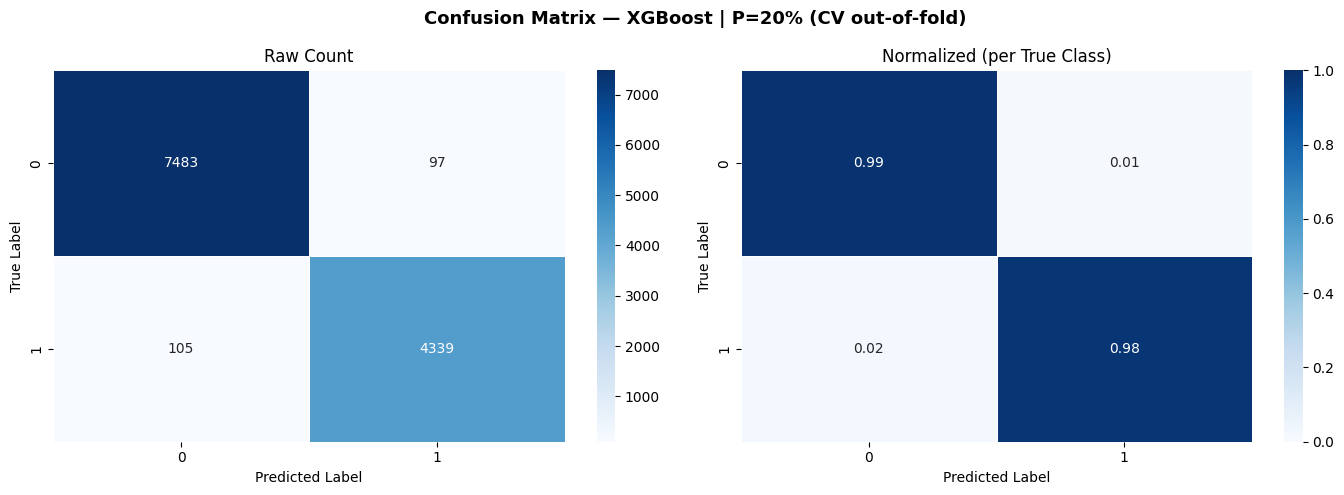


  Classification Report (Hold-out Test) — XGBoost, P=20%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.98      0.99      0.98      3007
weighted avg       0.99      0.99      0.99      3007



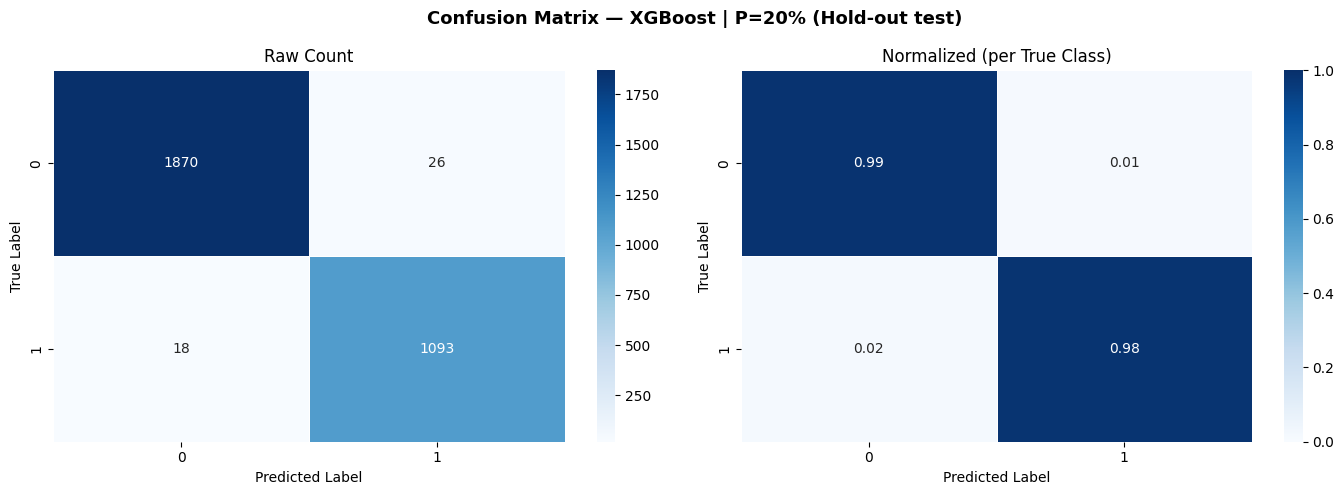


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 12.2117s

  Skor per fold — LightGBM, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9871    0.9861       0.9871           0.9870        0.9854
    2           2405    0.9850    0.9839       0.9850           0.9848        0.9830
    3           2405    0.9817    0.9804       0.9817           0.9799        0.9808
    4           2405    0.9792    0.9777       0.9792           0.9779        0.9775
    5           2404    0.9813    0.9799       0.9813           0.9798        0.9800

  Classification Report (CV, out-of-fold) — LightGBM, P=20%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.98      0.98      0.98      4444

    accuracy                           0.98     12024
   macro avg       0.98      0.98      0.98     12024
weighted avg       0.98      0.98      0.98     12024



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


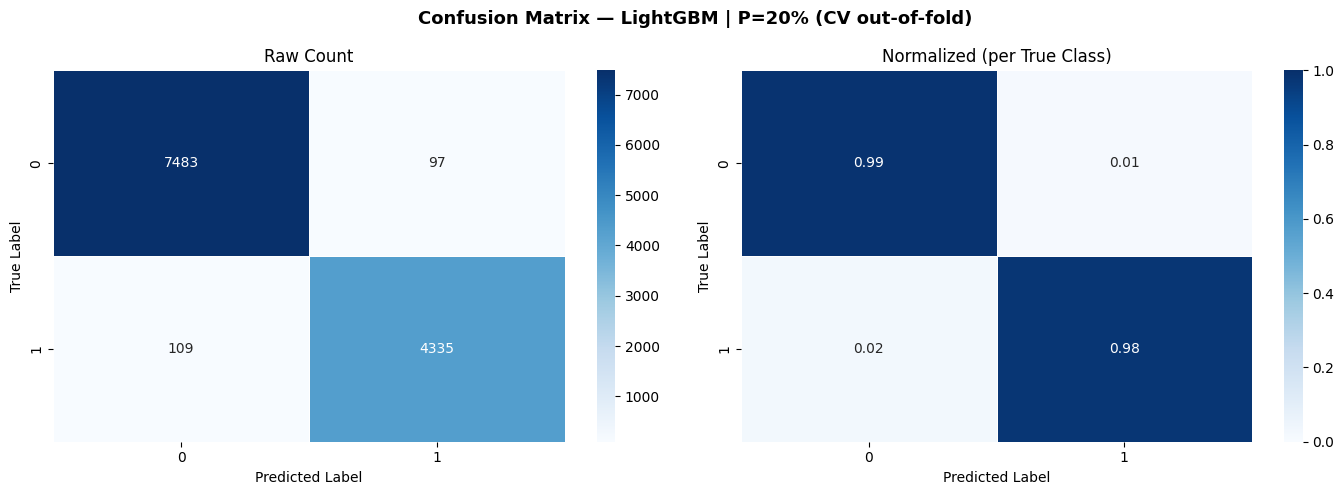


  Classification Report (Hold-out Test) — LightGBM, P=20%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.97      0.98      0.98      1111

    accuracy                           0.98      3007
   macro avg       0.98      0.98      0.98      3007
weighted avg       0.98      0.98      0.98      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


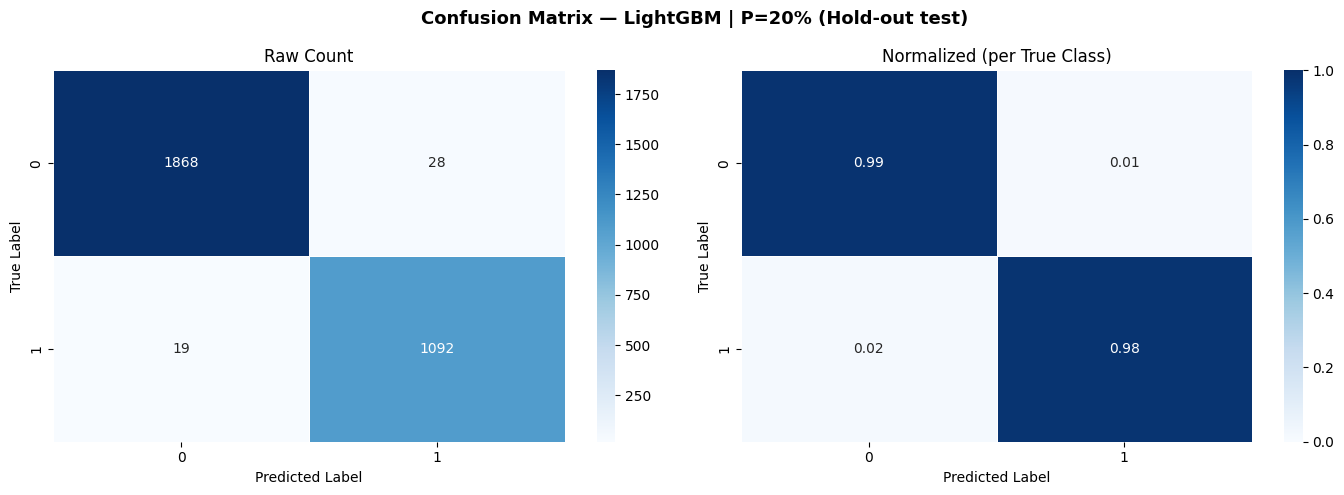


  [RandomForest]
  CV Time (5-fold) : 9.3919s

  Skor per fold — RandomForest, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9792    0.9776       0.9792           0.9795        0.9758
    2           2405    0.9834    0.9821       0.9833           0.9837        0.9805
    3           2405    0.9813    0.9799       0.9813           0.9796        0.9803
    4           2405    0.9863    0.9852       0.9863           0.9870        0.9835
    5           2404    0.9796    0.9781       0.9796           0.9789        0.9773

  Classification Report (CV, out-of-fold) — RandomForest, P=20%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.98      0.97      0.98      4444

    accuracy                           0.98     12024
   macro avg       0.98      0.98      0.98     12024
weighted avg       0.98      0.98      0.98     12024



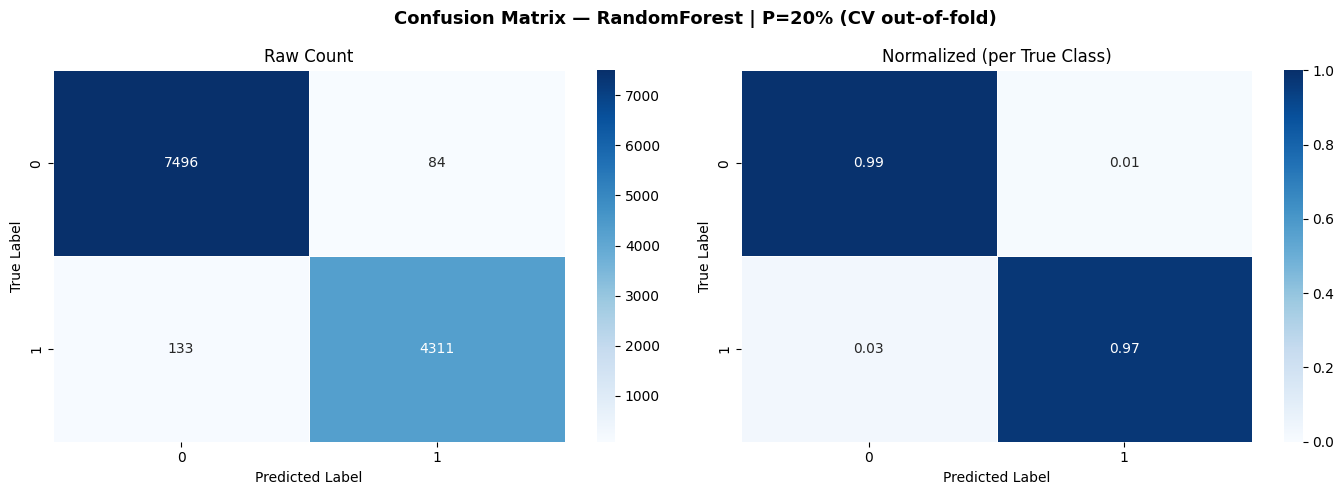


  Classification Report (Hold-out Test) — RandomForest, P=20%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.97      0.98      1111

    accuracy                           0.98      3007
   macro avg       0.98      0.98      0.98      3007
weighted avg       0.98      0.98      0.98      3007



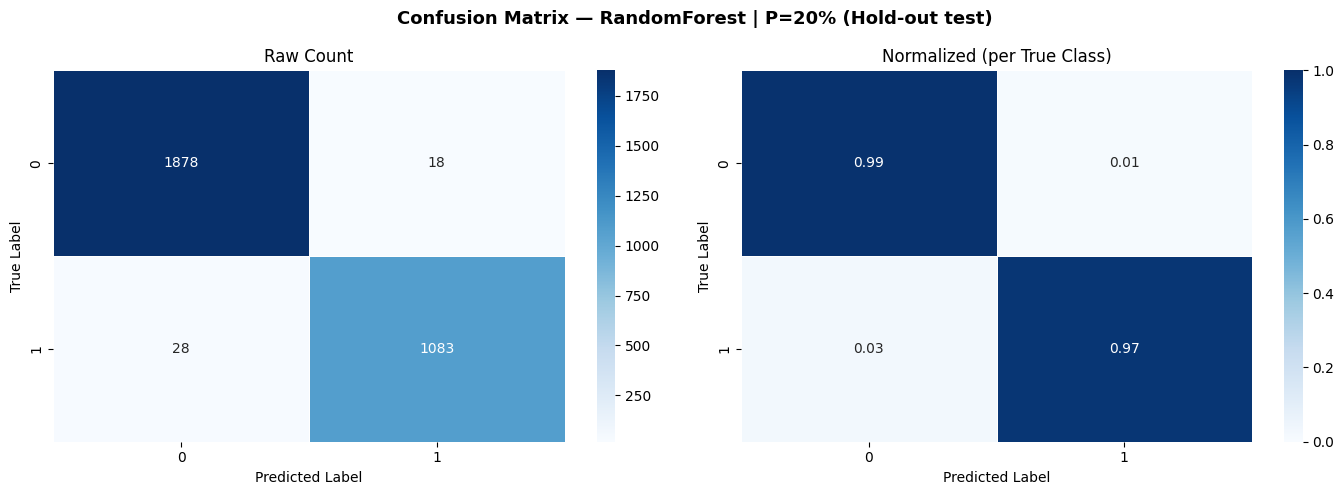


  Persentil P=30% -> 65 fitur

  [XGBoost]
  CV Time (5-fold) : 7.7383s

  Skor per fold — XGBoost, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9830    0.9817       0.9830           0.9812        0.9823
    2           2405    0.9867    0.9857       0.9867           0.9869        0.9846
    3           2405    0.9863    0.9853       0.9863           0.9850        0.9856
    4           2405    0.9859    0.9848       0.9858           0.9860        0.9837
    5           2404    0.9859    0.9848       0.9859           0.9850        0.9846

  Classification Report (CV, out-of-fold) — XGBoost, P=30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.98      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.98      0.98      0.98     12024
weighted avg       0.99      0.99      0.99     1

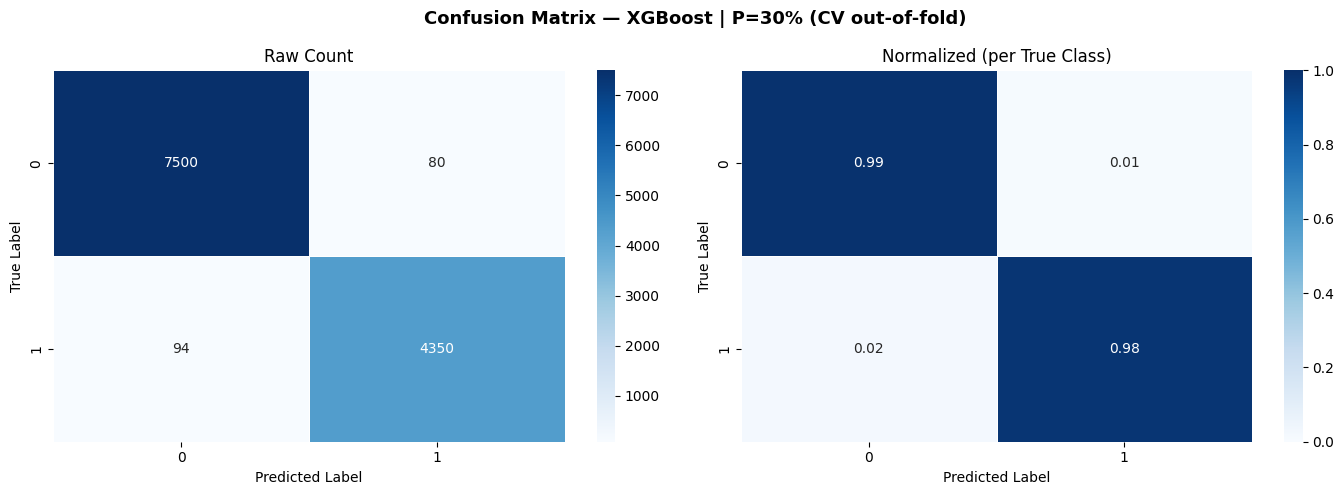


  Classification Report (Hold-out Test) — XGBoost, P=30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



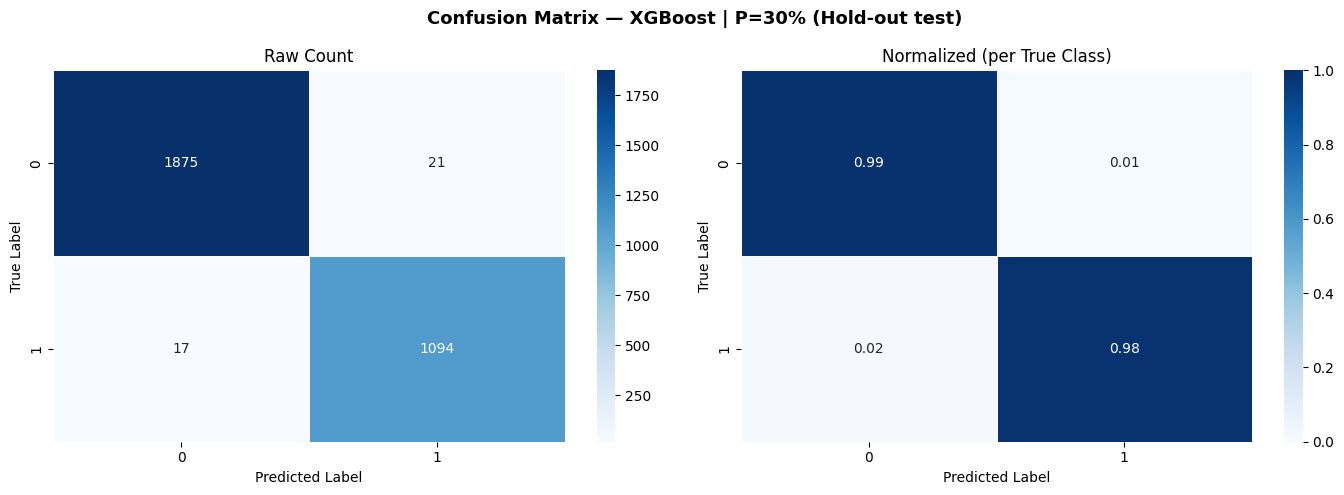


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 12.2759s

  Skor per fold — LightGBM, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9859    0.9848       0.9859           0.9848        0.9848
    2           2405    0.9875    0.9866       0.9875           0.9875        0.9857
    3           2405    0.9834    0.9822       0.9834           0.9822        0.9822
    4           2405    0.9867    0.9857       0.9867           0.9866        0.9848
    5           2404    0.9871    0.9862       0.9871           0.9863        0.9860

  Classification Report (CV, out-of-fold) — LightGBM, P=30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.98      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.99     12024
weighted avg       0.99      0.99      0.99     12024



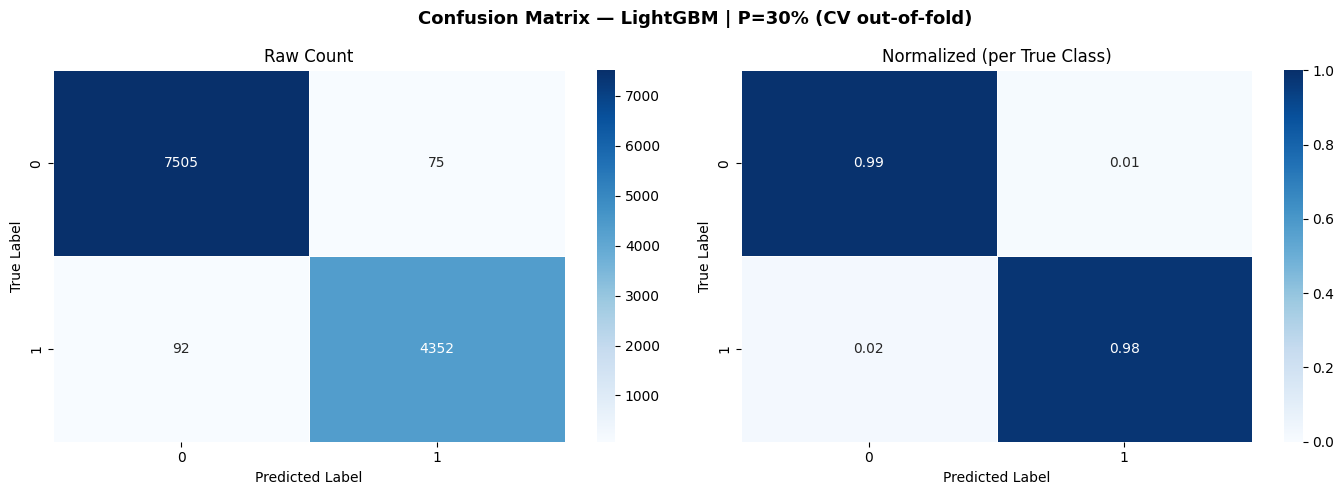


  Classification Report (Hold-out Test) — LightGBM, P=30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


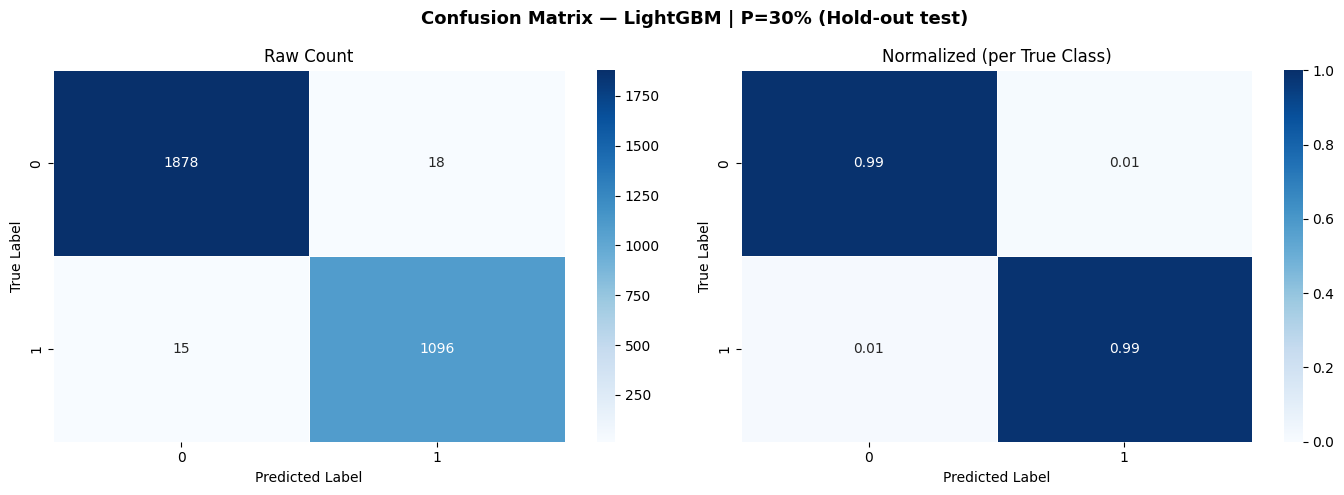


  [RandomForest]
  CV Time (5-fold) : 10.6271s

  Skor per fold — RandomForest, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9830    0.9816       0.9829           0.9834        0.9800
    2           2405    0.9863    0.9852       0.9863           0.9868        0.9838
    3           2405    0.9834    0.9821       0.9834           0.9824        0.9819
    4           2405    0.9854    0.9843       0.9854           0.9859        0.9829
    5           2404    0.9829    0.9816       0.9829           0.9834        0.9799

  Classification Report (CV, out-of-fold) — RandomForest, P=30%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.98      0.97      0.98      4444

    accuracy                           0.98     12024
   macro avg       0.98      0.98      0.98     12024
weighted avg       0.98      0.98      0.98     12024



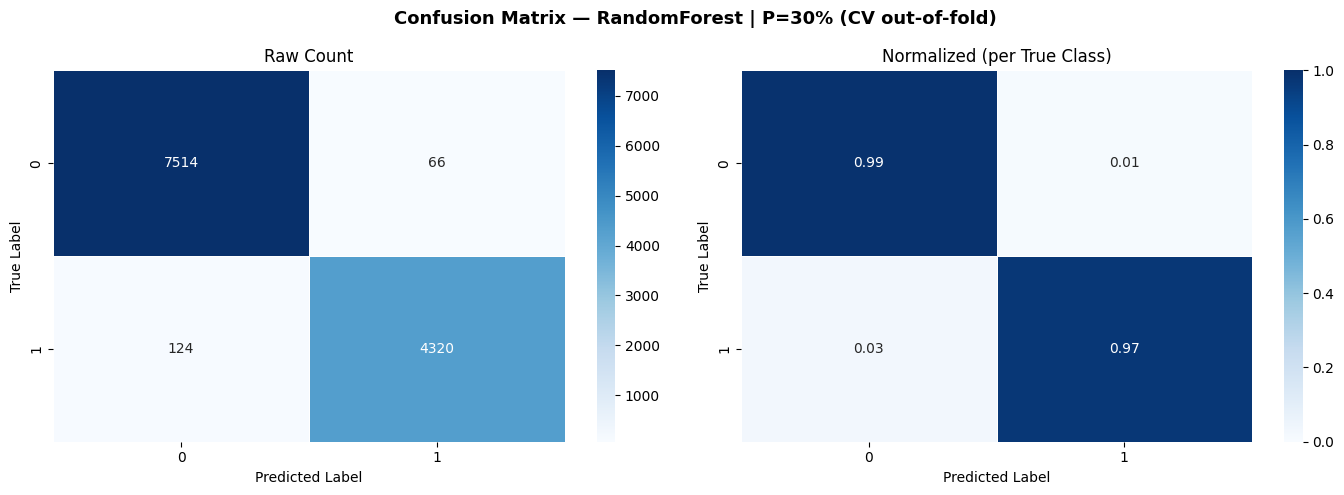


  Classification Report (Hold-out Test) — RandomForest, P=30%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.97      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



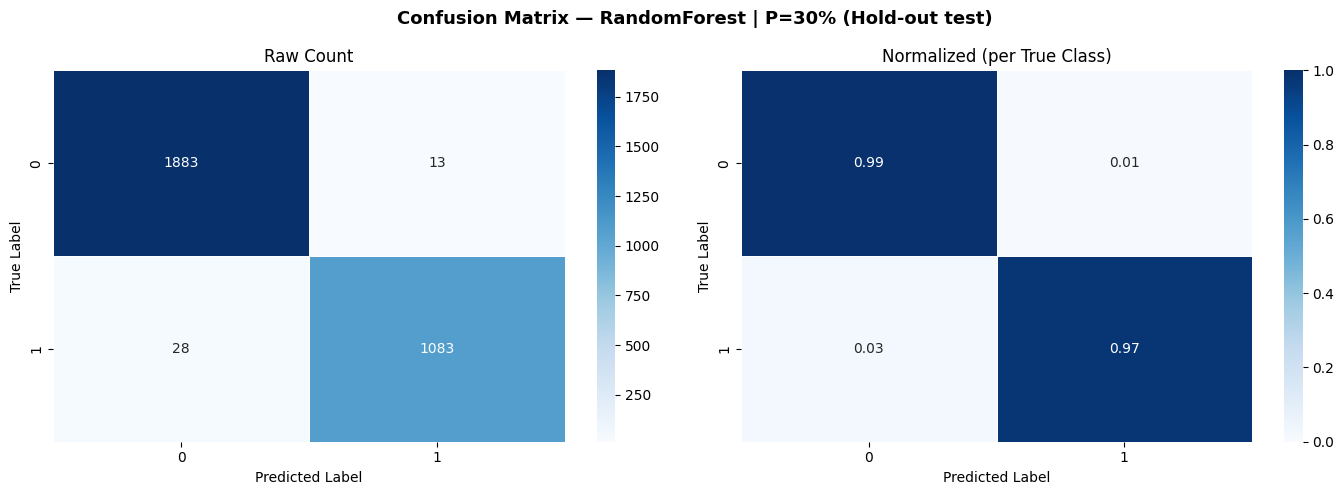


  Persentil P=40% -> 86 fitur

  [XGBoost]
  CV Time (5-fold) : 3.3741s

  Skor per fold — XGBoost, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9859    0.9848       0.9859           0.9848        0.9848
    2           2405    0.9888    0.9879       0.9888           0.9892        0.9867
    3           2405    0.9888    0.9880       0.9888           0.9878        0.9881
    4           2405    0.9875    0.9866       0.9875           0.9878        0.9855
    5           2404    0.9896    0.9888       0.9896           0.9890        0.9887

  Classification Report (CV, out-of-fold) — XGBoost, P=40%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     1

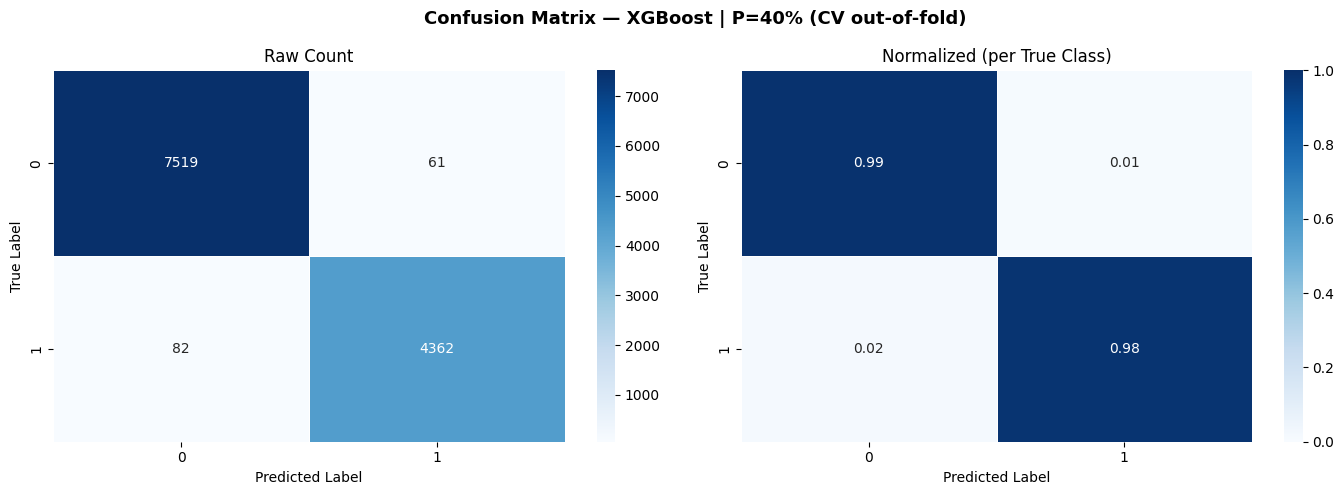


  Classification Report (Hold-out Test) — XGBoost, P=40%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.98      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



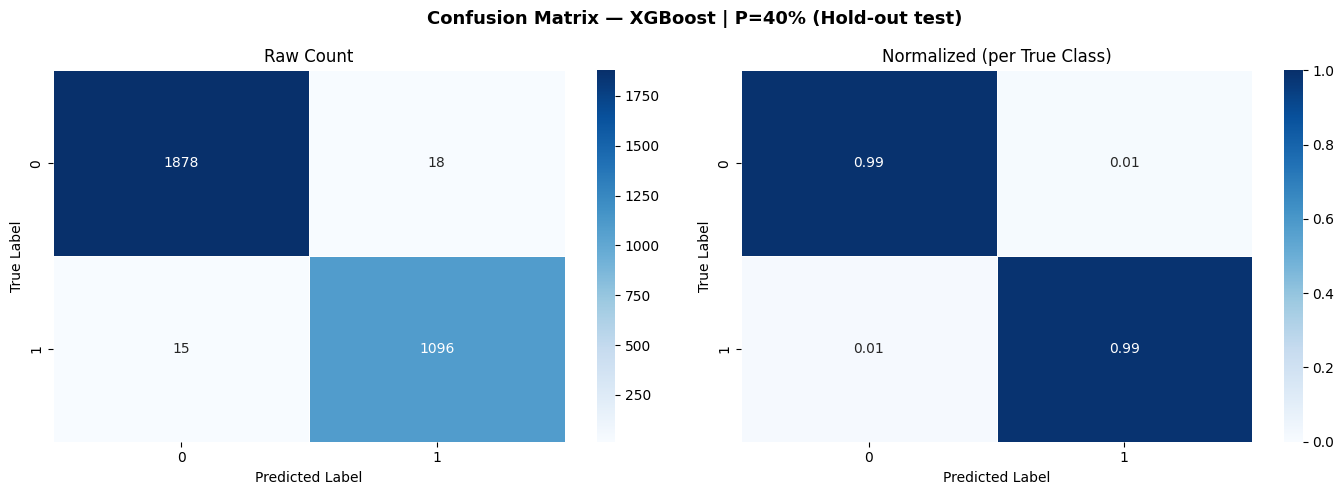


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 7.4608s

  Skor per fold — LightGBM, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9875    0.9866       0.9875           0.9866        0.9866
    2           2405    0.9892    0.9884       0.9892           0.9900        0.9868
    3           2405    0.9863    0.9853       0.9863           0.9852        0.9854
    4           2405    0.9875    0.9866       0.9875           0.9873        0.9859
    5           2404    0.9879    0.9871       0.9879           0.9869        0.9872

  Classification Report (CV, out-of-fold) — LightGBM, P=40%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     12024



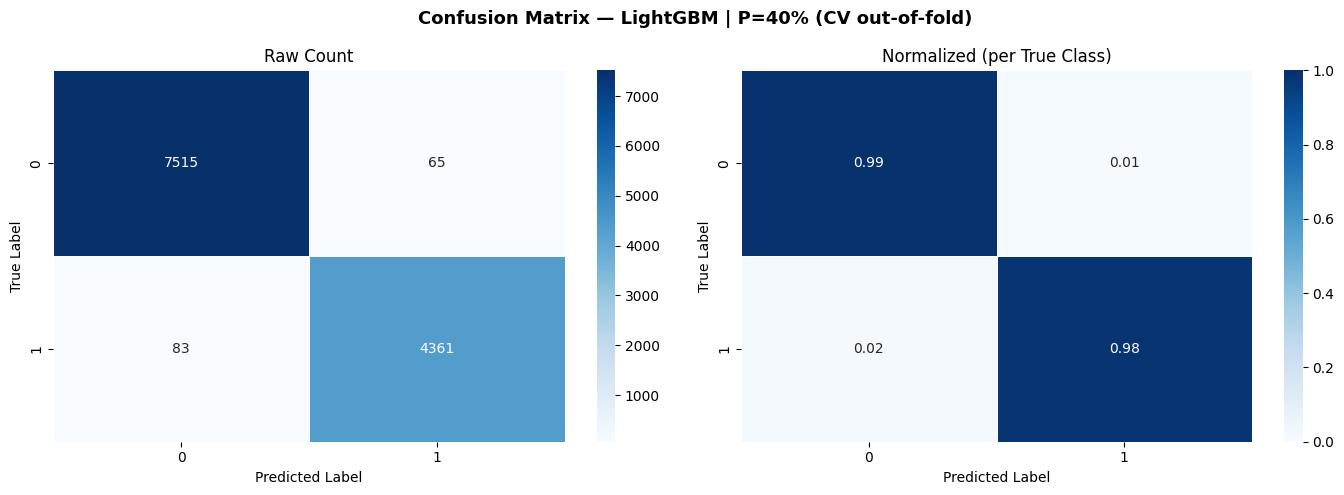


  Classification Report (Hold-out Test) — LightGBM, P=40%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


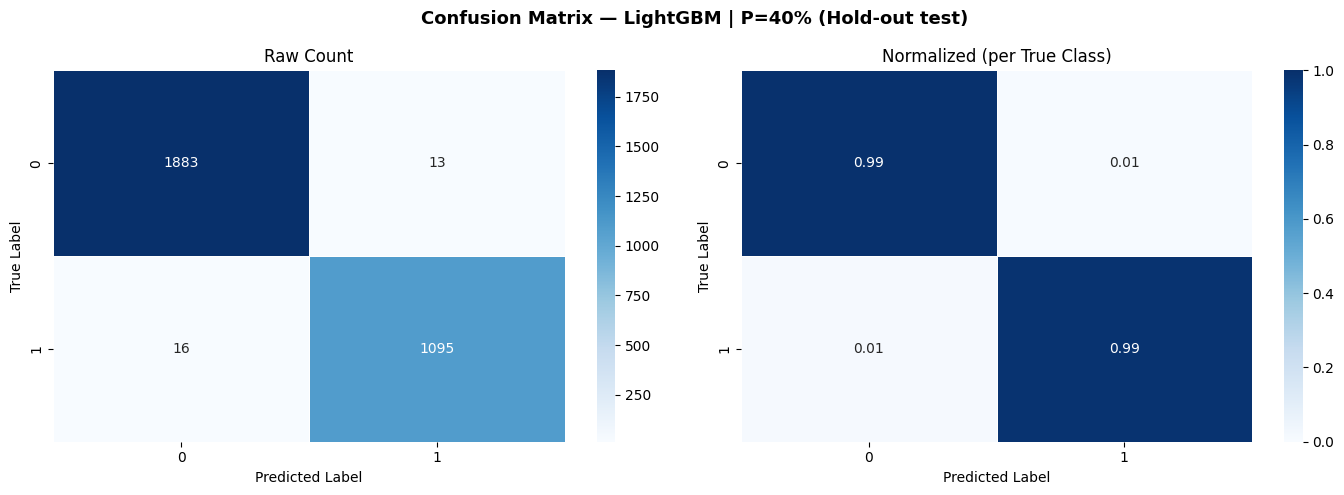


  [RandomForest]
  CV Time (5-fold) : 5.8061s

  Skor per fold — RandomForest, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9846    0.9834       0.9846           0.9850        0.9820
    2           2405    0.9892    0.9883       0.9892           0.9908        0.9861
    3           2405    0.9850    0.9839       0.9850           0.9846        0.9832
    4           2405    0.9867    0.9857       0.9867           0.9878        0.9836
    5           2404    0.9838    0.9826       0.9838           0.9836        0.9815

  Classification Report (CV, out-of-fold) — RandomForest, P=40%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.99      0.97      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.98     12024
weighted avg       0.99      0.99      0.99     12024



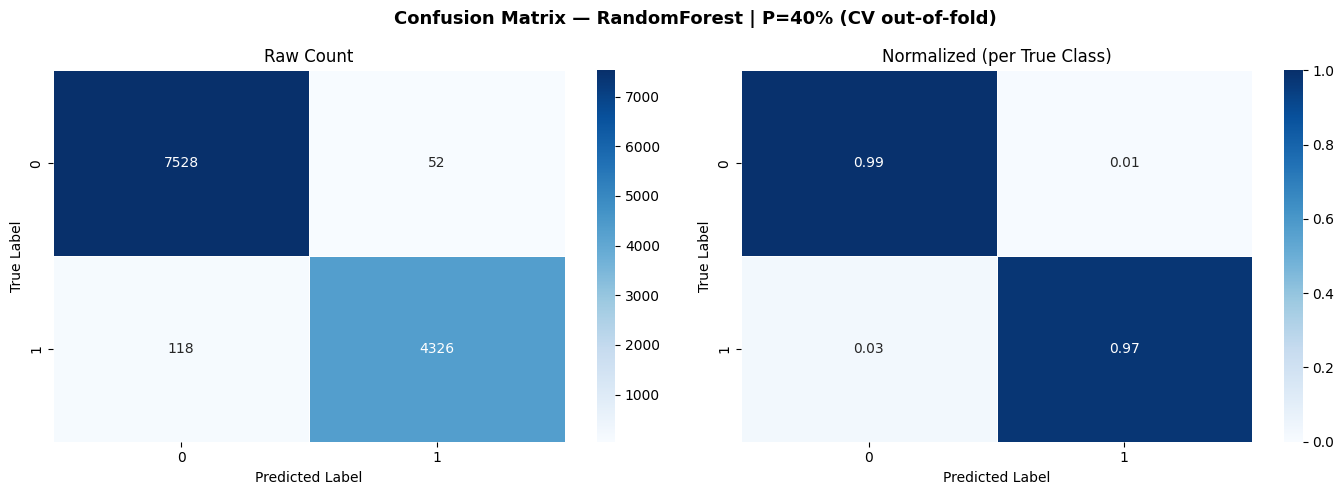


  Classification Report (Hold-out Test) — RandomForest, P=40%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



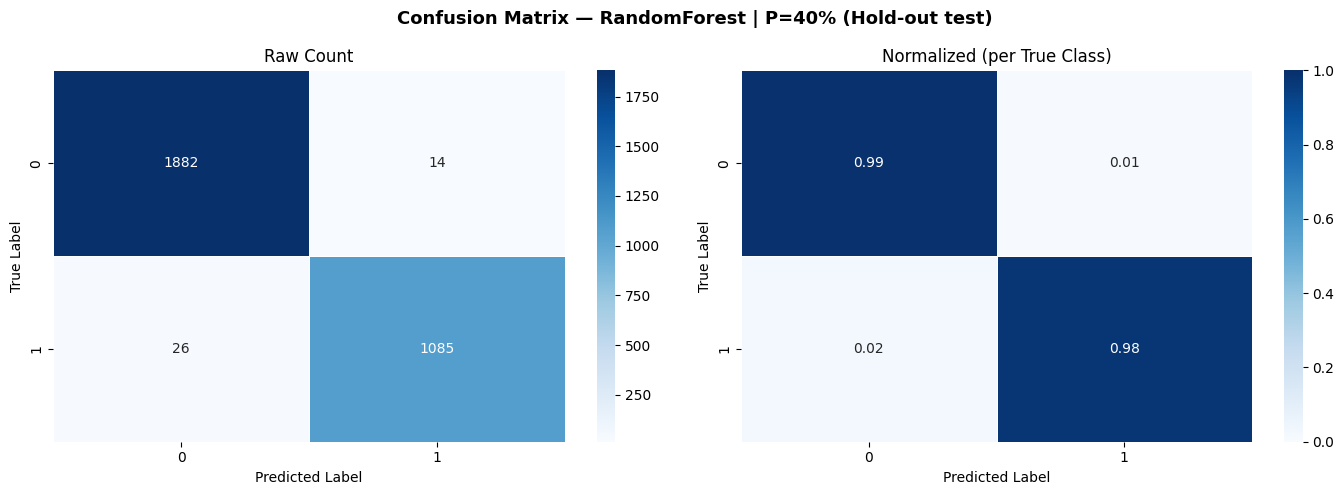


  Persentil P=50% -> 108 fitur

  [XGBoost]
  CV Time (5-fold) : 3.5156s

  Skor per fold — XGBoost, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9854    0.9844       0.9855           0.9841        0.9847
    2           2405    0.9875    0.9866       0.9875           0.9873        0.9859
    3           2405    0.9888    0.9880       0.9888           0.9874        0.9885
    4           2405    0.9875    0.9866       0.9875           0.9878        0.9855
    5           2404    0.9908    0.9902       0.9908           0.9906        0.9897

  Classification Report (CV, out-of-fold) — XGBoost, P=50%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     

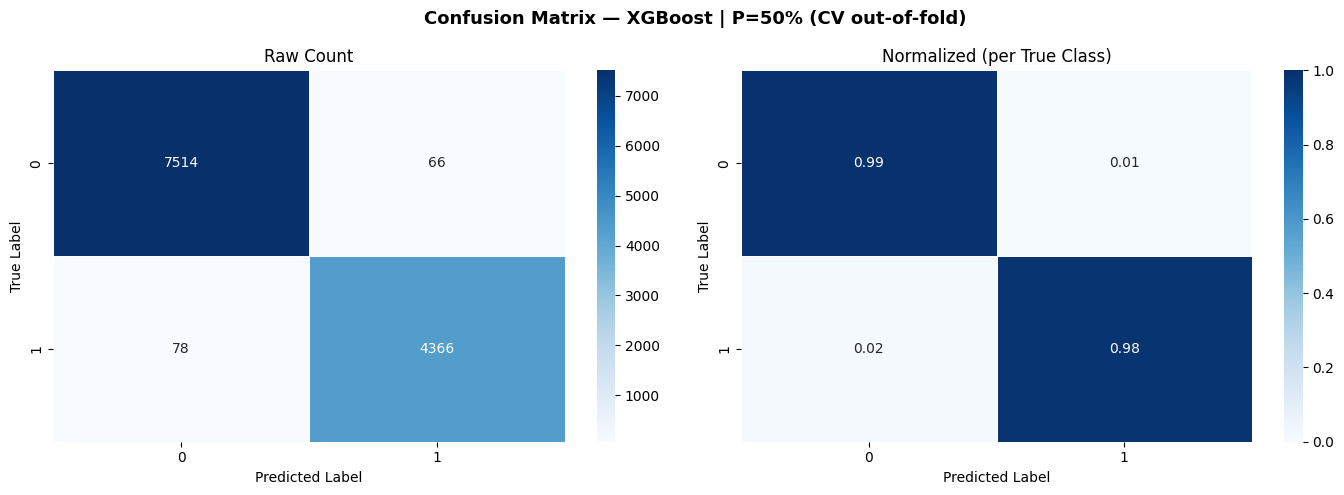


  Classification Report (Hold-out Test) — XGBoost, P=50%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



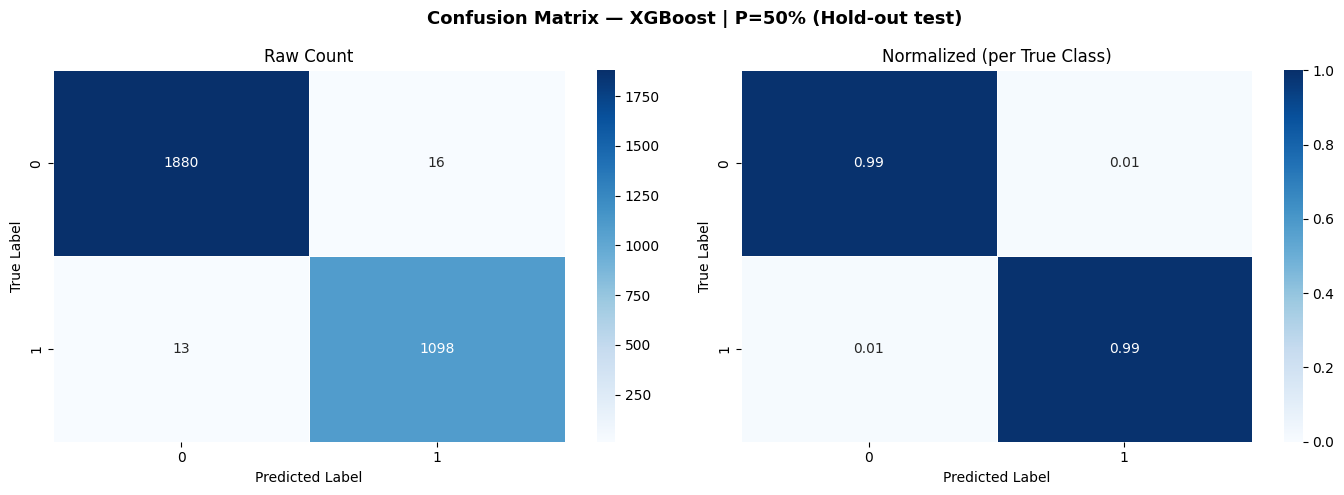


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 7.2437s

  Skor per fold — LightGBM, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9884    0.9875       0.9884           0.9873        0.9877
    2           2405    0.9892    0.9884       0.9892           0.9891        0.9877
    3           2405    0.9896    0.9888       0.9896           0.9887        0.9890
    4           2405    0.9884    0.9875       0.9883           0.9882        0.9868
    5           2404    0.9896    0.9888       0.9896           0.9892        0.9885

  Classification Report (CV, out-of-fold) — LightGBM, P=50%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.99      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     12024



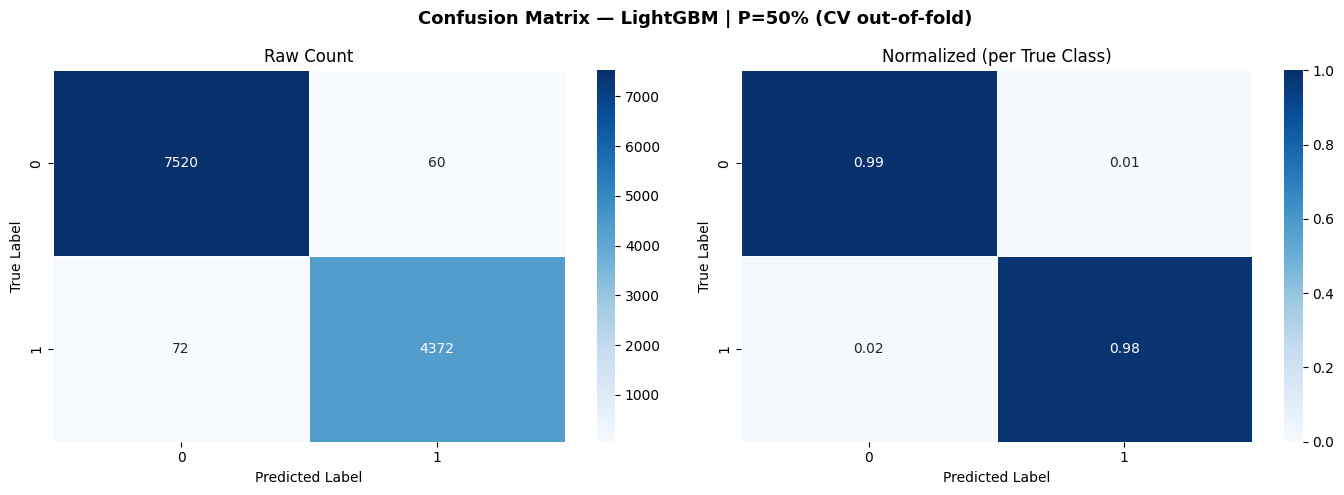


  Classification Report (Hold-out Test) — LightGBM, P=50%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


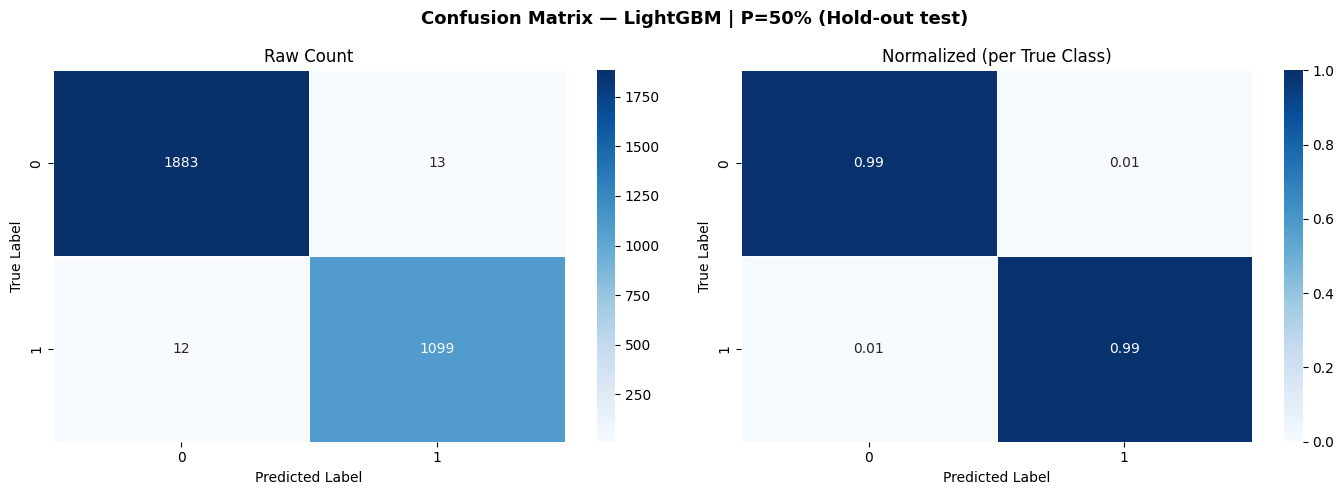


  [RandomForest]
  CV Time (5-fold) : 6.0405s

  Skor per fold — RandomForest, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9842    0.9830       0.9842           0.9851        0.9810
    2           2405    0.9896    0.9888       0.9896           0.9914        0.9864
    3           2405    0.9842    0.9830       0.9842           0.9842        0.9819
    4           2405    0.9867    0.9857       0.9867           0.9878        0.9836
    5           2404    0.9850    0.9839       0.9850           0.9851        0.9828

  Classification Report (CV, out-of-fold) — RandomForest, P=50%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.99      0.97      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.98     12024
weighted avg       0.99      0.99      0.99     12024



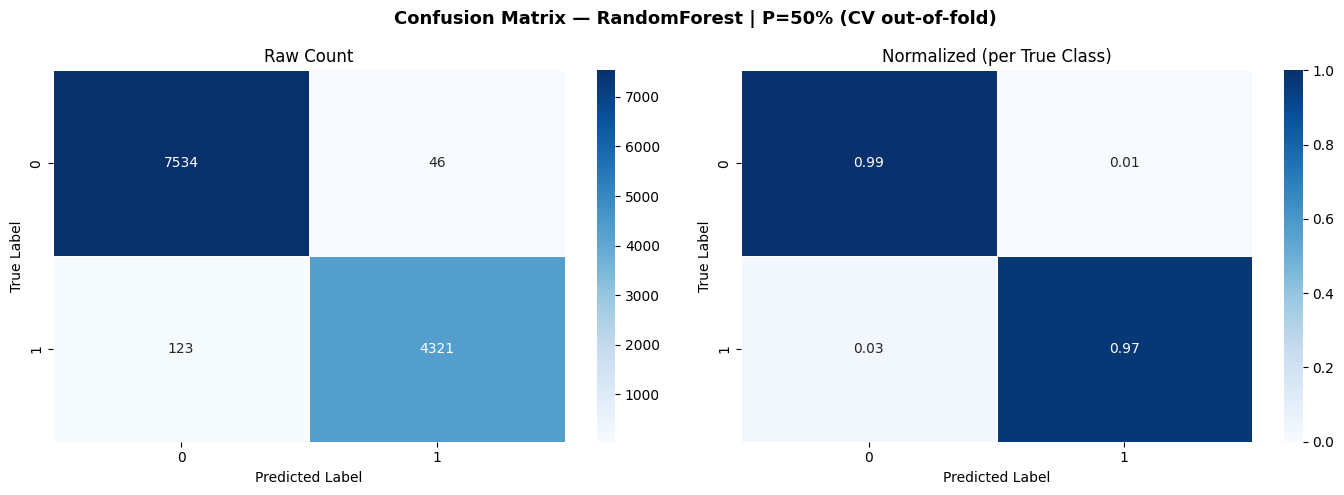


  Classification Report (Hold-out Test) — RandomForest, P=50%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007



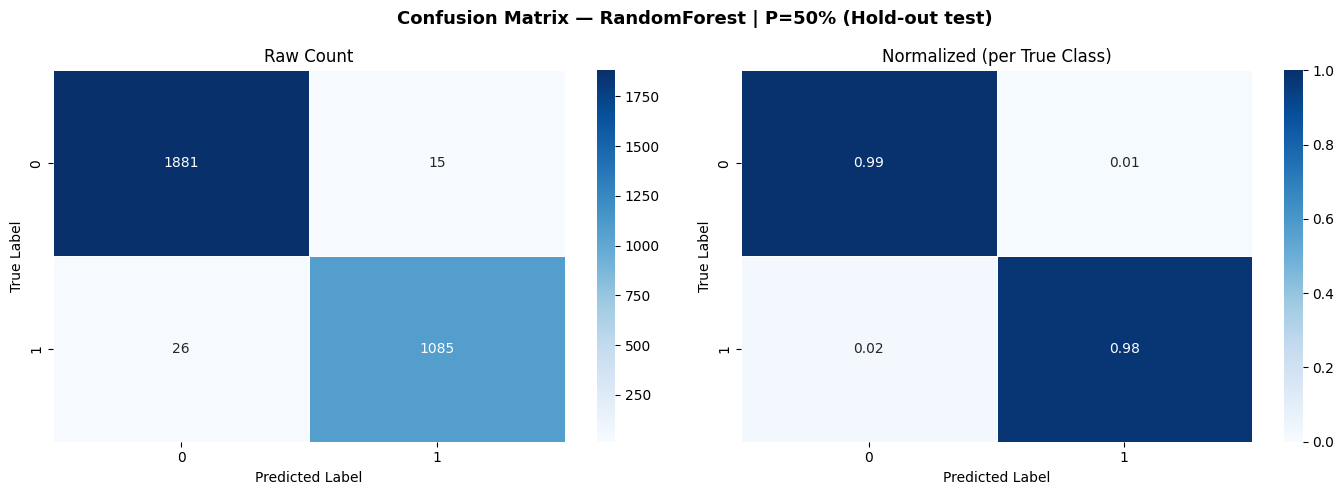


  Persentil P=60% -> 129 fitur

  [XGBoost]
  CV Time (5-fold) : 3.8897s

  Skor per fold — XGBoost, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9867    0.9857       0.9867           0.9855        0.9860
    2           2405    0.9875    0.9866       0.9875           0.9873        0.9859
    3           2405    0.9888    0.9880       0.9888           0.9876        0.9883
    4           2405    0.9884    0.9875       0.9883           0.9887        0.9863
    5           2404    0.9900    0.9893       0.9900           0.9897        0.9888

  Classification Report (CV, out-of-fold) — XGBoost, P=60%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     

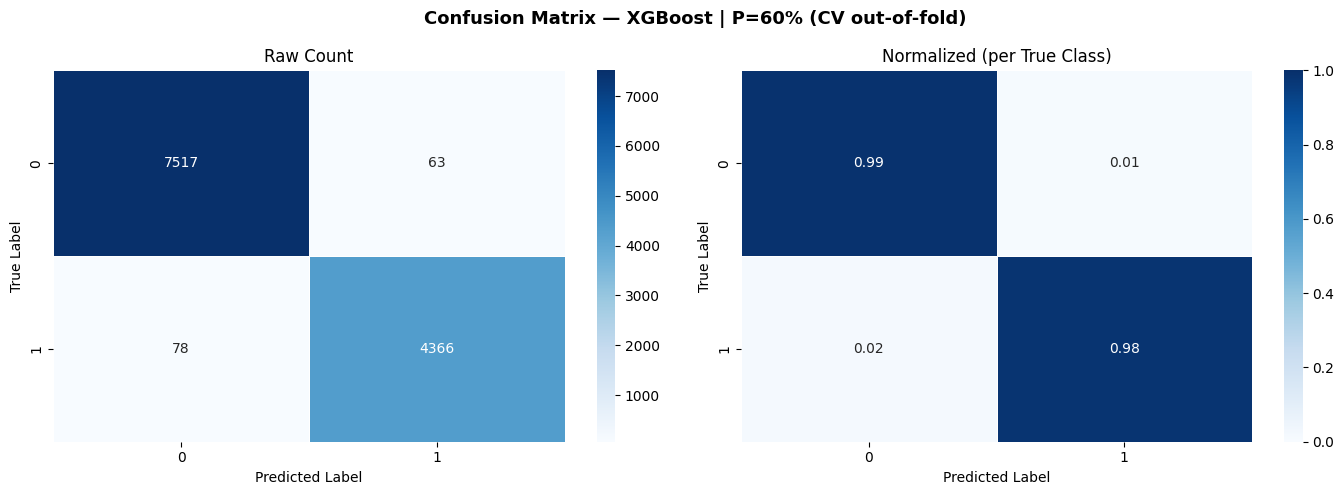


  Classification Report (Hold-out Test) — XGBoost, P=60%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



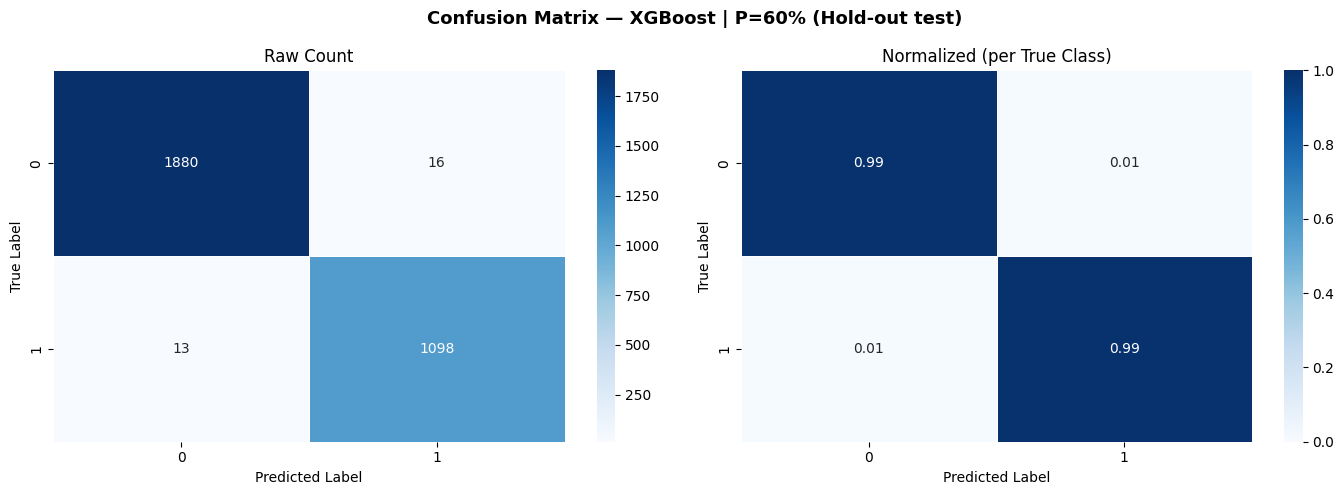


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 7.5837s

  Skor per fold — LightGBM, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9896    0.9888       0.9896           0.9890        0.9887
    2           2405    0.9900    0.9893       0.9900           0.9907        0.9879
    3           2405    0.9900    0.9893       0.9900           0.9893        0.9893
    4           2405    0.9900    0.9893       0.9900           0.9909        0.9877
    5           2404    0.9908    0.9902       0.9908           0.9906        0.9897

  Classification Report (CV, out-of-fold) — LightGBM, P=60%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.99      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     12024



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


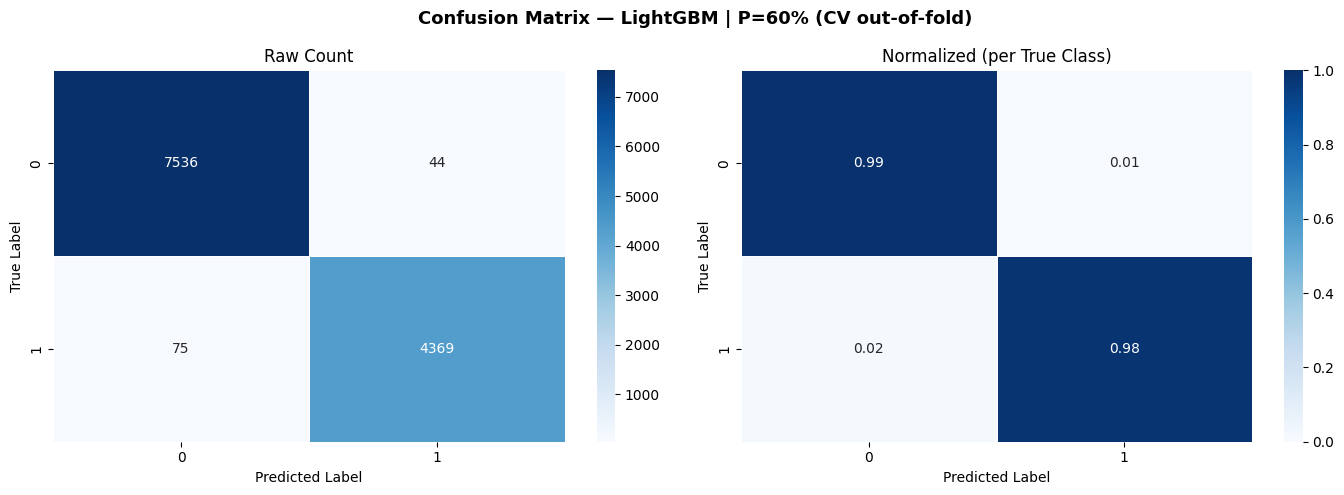


  Classification Report (Hold-out Test) — LightGBM, P=60%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


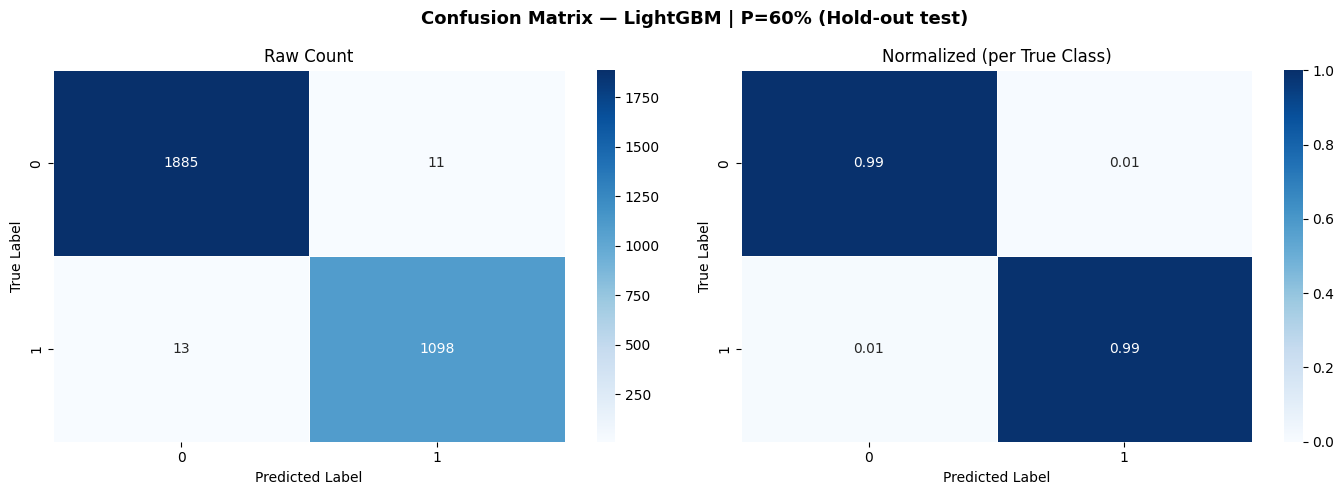


  [RandomForest]
  CV Time (5-fold) : 6.6277s

  Skor per fold — RandomForest, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9859    0.9848       0.9858           0.9864        0.9832
    2           2405    0.9900    0.9892       0.9900           0.9914        0.9872
    3           2405    0.9830    0.9817       0.9829           0.9825        0.9809
    4           2405    0.9879    0.9870       0.9879           0.9891        0.9851
    5           2404    0.9829    0.9816       0.9829           0.9829        0.9804

  Classification Report (CV, out-of-fold) — RandomForest, P=60%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.99      0.97      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.98     12024
weighted avg       0.99      0.99      0.99     12024



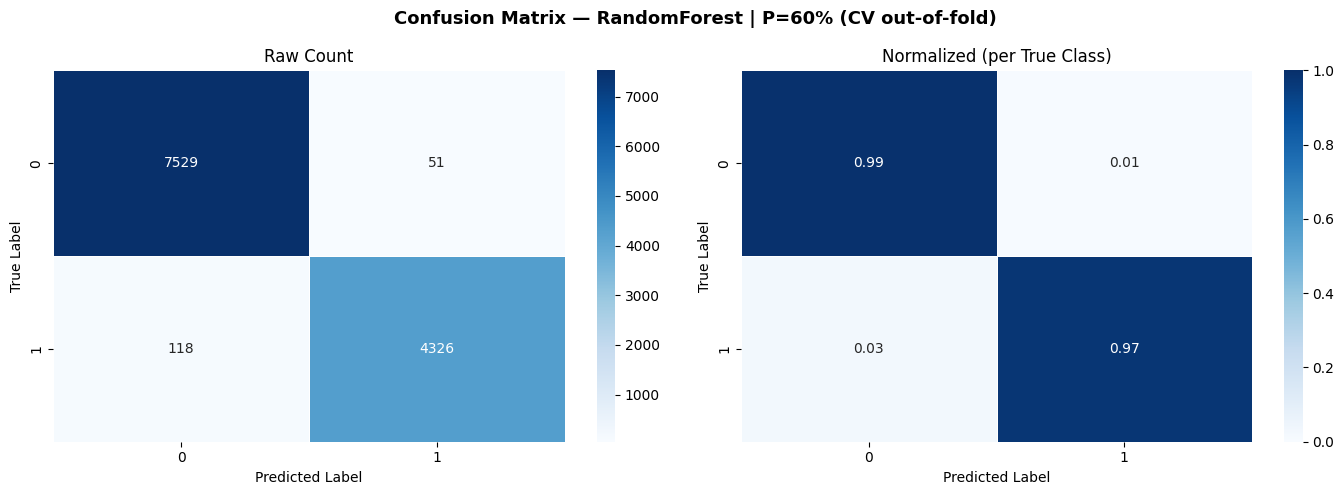


  Classification Report (Hold-out Test) — RandomForest, P=60%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



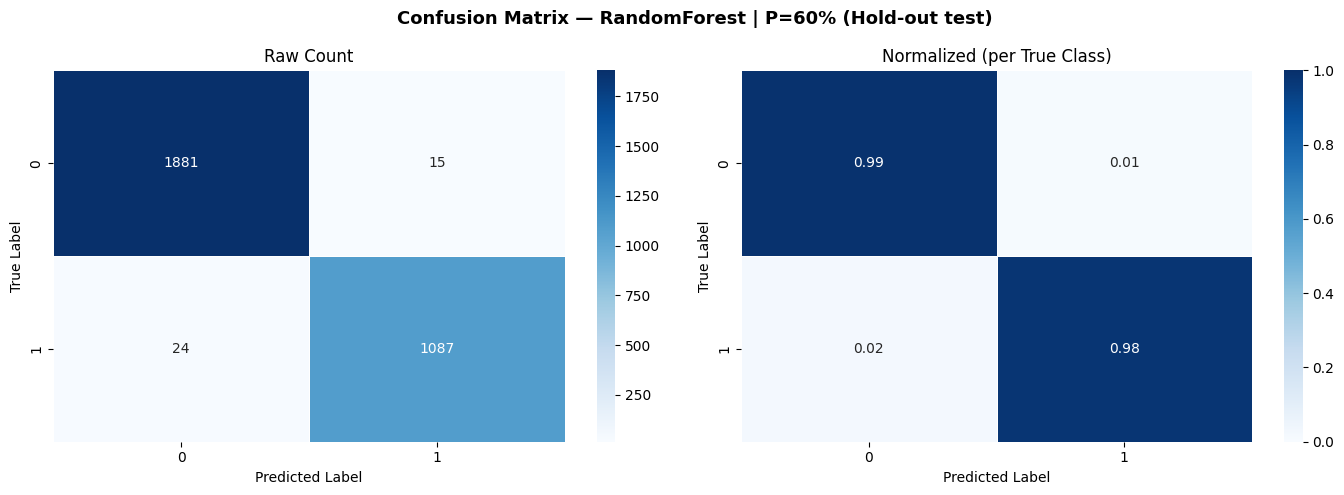


  Persentil P=70% -> 151 fitur

  [XGBoost]
  CV Time (5-fold) : 3.9727s

  Skor per fold — XGBoost, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9863    0.9853       0.9863           0.9850        0.9856
    2           2405    0.9888    0.9879       0.9888           0.9890        0.9869
    3           2405    0.9904    0.9897       0.9904           0.9896        0.9899
    4           2405    0.9875    0.9866       0.9875           0.9875        0.9857
    5           2404    0.9908    0.9902       0.9908           0.9904        0.9899

  Classification Report (CV, out-of-fold) — XGBoost, P=70%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     

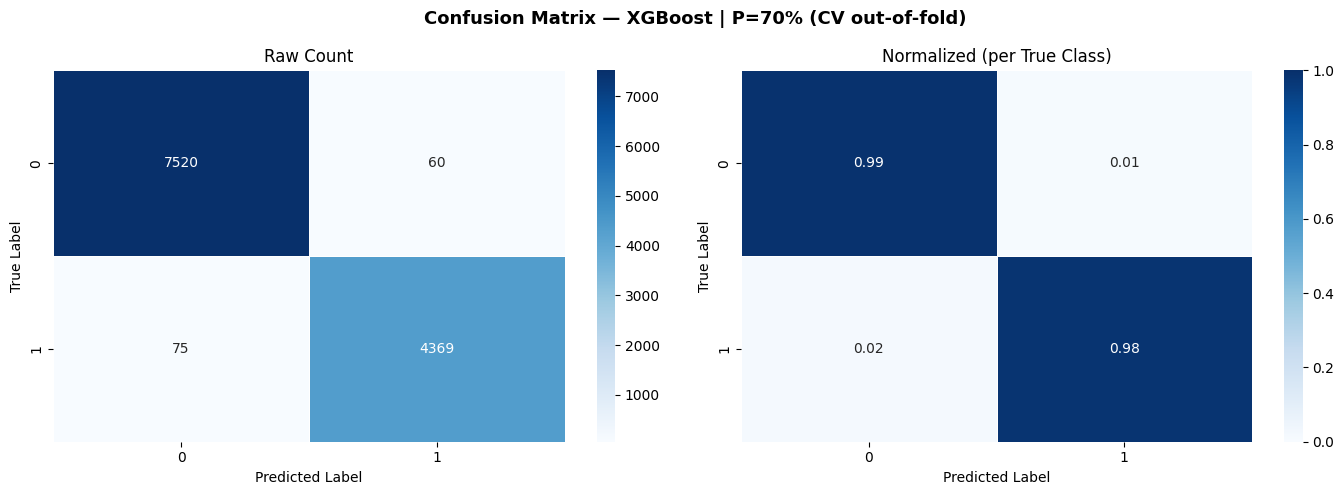


  Classification Report (Hold-out Test) — XGBoost, P=70%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



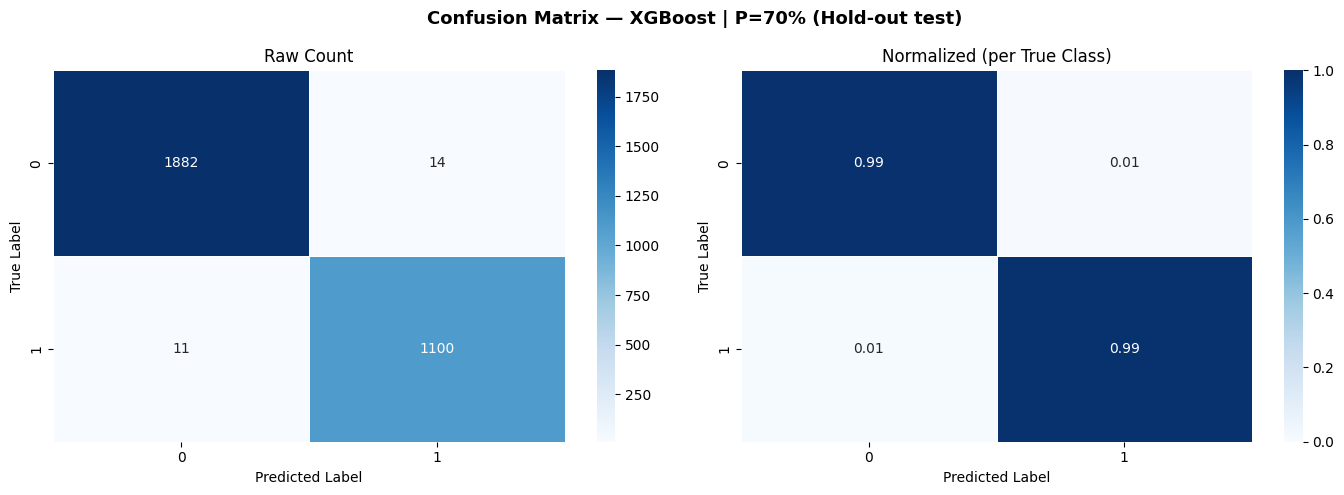


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 7.7995s

  Skor per fold — LightGBM, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9896    0.9888       0.9896           0.9887        0.9890
    2           2405    0.9900    0.9893       0.9900           0.9904        0.9881
    3           2405    0.9896    0.9888       0.9896           0.9887        0.9890
    4           2405    0.9892    0.9884       0.9892           0.9896        0.9872
    5           2404    0.9904    0.9897       0.9904           0.9903        0.9891

  Classification Report (CV, out-of-fold) — LightGBM, P=70%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7580
           1       0.99      0.98      0.99      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.99      0.99     12024
weighted avg       0.99      0.99      0.99     12024



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


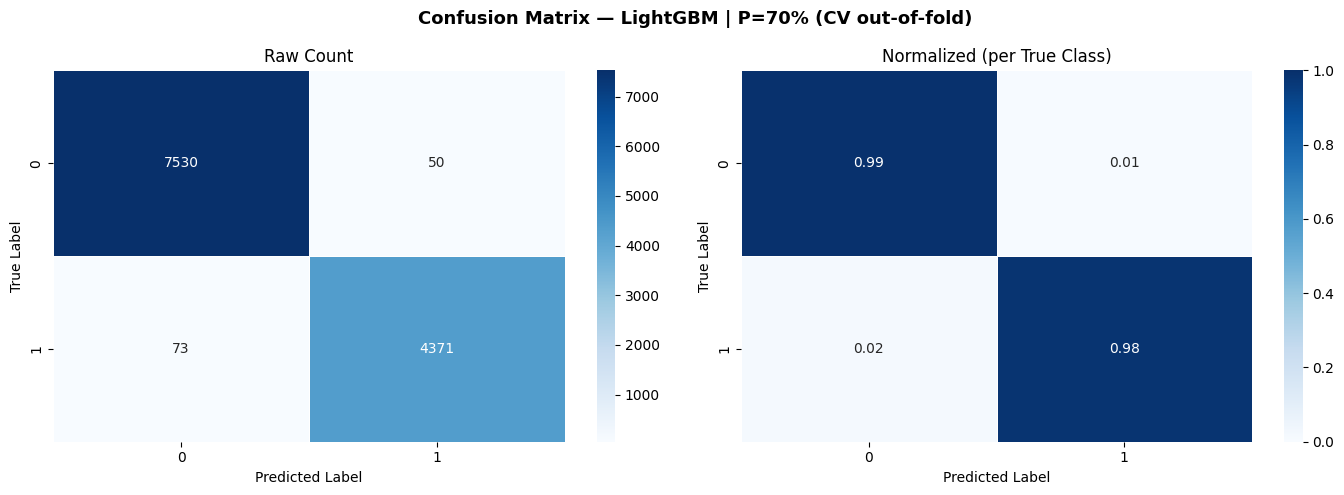


  Classification Report (Hold-out Test) — LightGBM, P=70%:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1896
           1       0.99      0.99      0.99      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


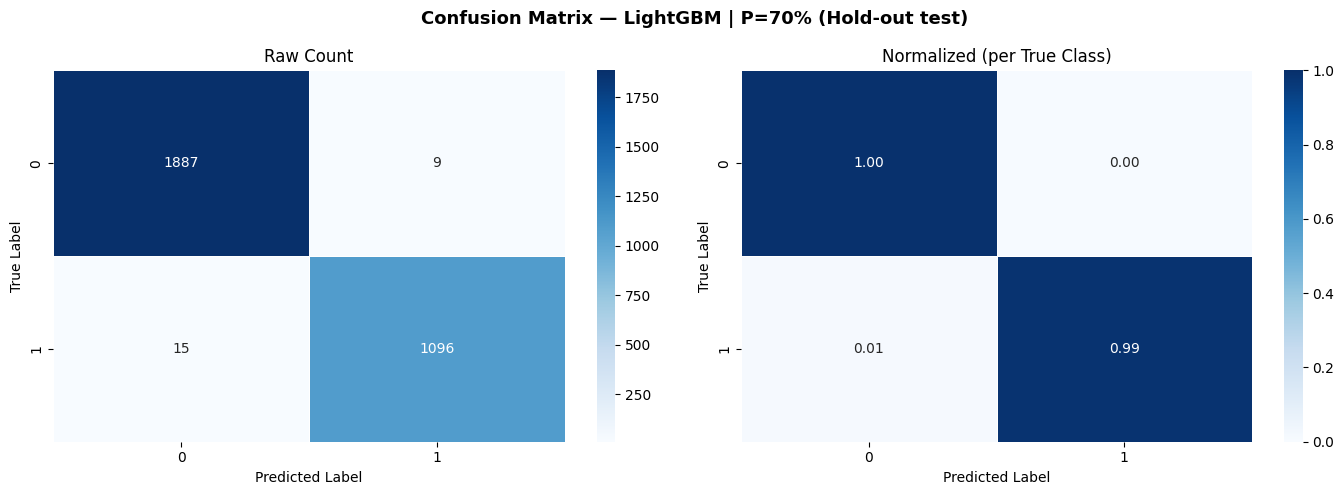


  [RandomForest]
  CV Time (5-fold) : 7.0291s

  Skor per fold — RandomForest, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1           2405    0.9859    0.9848       0.9858           0.9869        0.9827
    2           2405    0.9888    0.9879       0.9887           0.9902        0.9857
    3           2405    0.9854    0.9844       0.9854           0.9849        0.9838
    4           2405    0.9871    0.9861       0.9871           0.9879        0.9844
    5           2404    0.9834    0.9821       0.9833           0.9833        0.9810

  Classification Report (CV, out-of-fold) — RandomForest, P=70%:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      7580
           1       0.99      0.97      0.98      4444

    accuracy                           0.99     12024
   macro avg       0.99      0.98      0.99     12024
weighted avg       0.99      0.99      0.99     12024



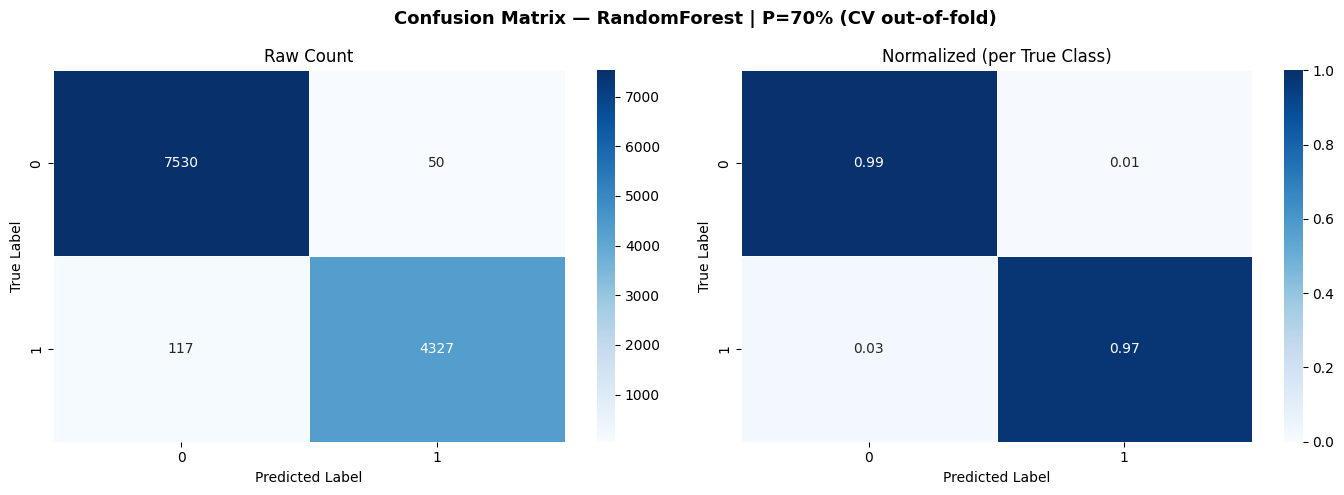


  Classification Report (Hold-out Test) — RandomForest, P=70%:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1896
           1       0.99      0.98      0.98      1111

    accuracy                           0.99      3007
   macro avg       0.99      0.99      0.99      3007
weighted avg       0.99      0.99      0.99      3007



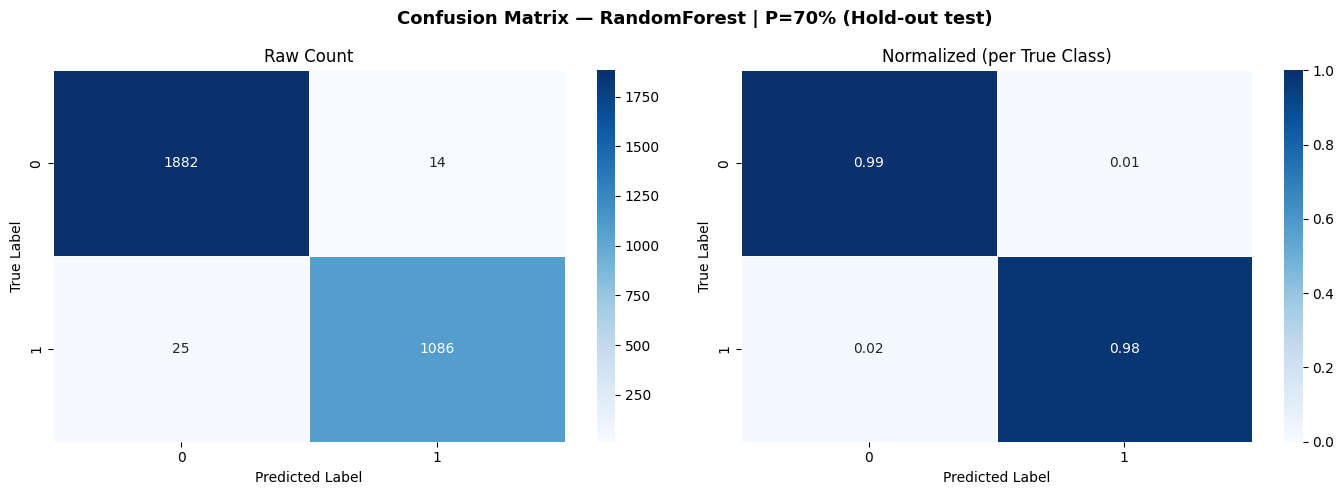

  PERSENTIL+SMOTETOMEK — SKOR PER FOLD, SEMUA KOMBINASI (long-format)
 Group  N Fitur        Model  Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Precision Weighted  Recall Macro  Recall Weighted
    10       22      XGBoost     1           2405    0.9655    0.9630       0.9655           0.9625              0.9655        0.9636           0.9655
    10       22      XGBoost     2           2405    0.9688    0.9664       0.9688           0.9681              0.9688        0.9648           0.9688
    10       22      XGBoost     3           2405    0.9655    0.9630       0.9655           0.9629              0.9655        0.9631           0.9655
    10       22      XGBoost     4           2405    0.9626    0.9600       0.9626           0.9584              0.9628        0.9617           0.9626
    10       22      XGBoost     5           2404    0.9621    0.9594       0.9622           0.9591              0.9622        0.9597           0.9621
    10       22     Ligh

In [14]:

 
# %% [markdown]
# ## 6. Loop Persentil Fitur x Model — SMOTETomek + Stratified K-Fold CV
#
# Untuk setiap persentil fitur teratas (berdasarkan SHAP importance) dan
# setiap model, pipeline `resampling -> scaling -> classifier` dievaluasi
# dengan CV manual per-fold (anti data leakage), lalu juga dievaluasi di
# hold-out test set.
 
# %%
percentiles = [10, 20, 30, 40, 50, 60, 70]
 
fs_models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.2, random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=None, learning_rate=0.2,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}
 
results_cv = {}
results_holdout = {}
cv_perfold_records = []
 
for P in percentiles:
    N_total = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()
 
    X_train_p = X_train[selected_features]
    X_test_p = X_test[selected_features]
 
    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% -> {N_FEATURES} fitur")
    print(f"{'='*60}")
 
    for model_name, clf in fs_models.items():
        print(f"\n  [{model_name}]")
 
        # Resampling & scaling HANYA melihat fold training di tiap iterasi CV
        steps = [
            ("resampling", SMOTETomek(random_state=RANDOM_STATE)),
            ("scaler", MinMaxScaler()),
            ("classifier", clf.__class__(**clf.get_params())),
        ]
 
        start = time.time()
        y_pred_cv, fold_records = run_manual_cv(
            steps, X_train_p, y_train, skf,
            group_label=P, n_features=N_FEATURES, model_name=model_name
        )
        cv_time = time.time() - start
        print(f"  CV Time ({N_SPLITS}-fold) : {cv_time:.4f}s")
 
        cv_perfold_records.extend(fold_records)
 
        # Tampilkan skor tiap fold (bukan cuma rata-rata) untuk kombinasi ini
        fold_preview_df = pd.DataFrame(fold_records).round(4)
        print(f"\n  Skor per fold — {model_name}, P={P}%:")
        print(fold_preview_df[[
            'Fold', 'N Val Samples', 'Accuracy', 'F1 Macro', 'F1 Weighted',
            'Precision Macro', 'Recall Macro'
        ]].to_string(index=False))
 
        print(f"\n  Classification Report (CV, out-of-fold) — {model_name}, P={P}%:")
        print(classification_report(y_train, y_pred_cv,
                                      target_names=[str(c) for c in class_labels], zero_division=0))
        plot_confusion_matrix(y_train, y_pred_cv,
                               f'Confusion Matrix — {model_name} | P={P}% (CV out-of-fold)', class_labels)
 
        results_cv[f'P{P}_{model_name}'] = summarize_cv_report(
            y_train, y_pred_cv, fold_records, P, N_FEATURES, model_name, cv_time
        )
 
        holdout_result, y_pred_test = evaluate_holdout(
            steps, X_train_p, y_train, X_test_p, y_test, P, N_FEATURES, model_name
        )
        results_holdout[f'P{P}_{model_name}'] = holdout_result
 
        print(f"\n  Classification Report (Hold-out Test) — {model_name}, P={P}%:")
        print(classification_report(y_test, y_pred_test,
                                      target_names=[str(c) for c in class_labels], zero_division=0))
        plot_confusion_matrix(y_test, y_pred_test,
                               f'Confusion Matrix — {model_name} | P={P}% (Hold-out test)', class_labels)
 
# %%
cv_perfold_df = pd.DataFrame(cv_perfold_records).round(4)
cv_perfold_df = cv_perfold_df[[
    'Group', 'N Fitur', 'Model', 'Fold', 'N Val Samples',
    'Accuracy', 'F1 Macro', 'F1 Weighted',
    'Precision Macro', 'Precision Weighted', 'Recall Macro', 'Recall Weighted'
]]
 
results_cv_df = pd.DataFrame(results_cv).T.round(4)
results_holdout_df = pd.DataFrame(results_holdout).T.round(4)
 
print("="*70)
print("  PERSENTIL+SMOTETOMEK — SKOR PER FOLD, SEMUA KOMBINASI (long-format)")
print("="*70)
print(cv_perfold_df.to_string(index=False))
 
print("\n" + "="*70)
print("  PERSENTIL+SMOTETOMEK — RATA-RATA CV PER KOMBINASI")
print("="*70)
print(results_cv_df.sort_values('F1 Macro', ascending=False).to_string())
 
best_cv = results_cv_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik (CV F1 Macro): Persentil={best_cv['Group']}%, "
      f"Model={best_cv['Model']}, F1 Macro={best_cv['F1 Macro']} "
      f"(std antar fold={best_cv['F1 Macro Std (antar fold)']})")
 
print("\n" + "="*70)
print("  PERSENTIL+SMOTETOMEK — HOLD-OUT TEST SET PER KOMBINASI")
print("="*70)
print(results_holdout_df.sort_values('F1 Macro', ascending=False).to_string())
 
best_holdout = results_holdout_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik (Hold-out F1 Macro): Persentil={best_holdout['Group']}%, "
      f"Model={best_holdout['Model']}, F1 Macro={best_holdout['F1 Macro']}")
 
# %%
comparison_df = pd.DataFrame({
    'F1 Macro (CV, rata-rata)' : results_cv_df['F1 Macro'],
    'F1 Macro (Hold-out)'      : results_holdout_df['F1 Macro'],
}).round(4)
comparison_df['Selisih'] = (
    comparison_df['F1 Macro (CV, rata-rata)'] - comparison_df['F1 Macro (Hold-out)']
).round(4)
 
print("="*70)
print("  PERBANDINGAN SKOR CV vs HOLD-OUT (cek konsistensi / overfitting)")
print("="*70)
print(comparison_df.sort_values('F1 Macro (CV, rata-rata)', ascending=False).to_string())
 
 
# %% [markdown]
# ## 7. Gabungan Baseline + Persentil — Tabel Statistik & Ekspor CSV
#
# `all_perfold_df` menggabungkan skor per-fold dari Baseline (Bagian 4) dan
# semua kombinasi Persentil+SMOTETomek (Bagian 6) dalam satu tabel
# long-format. Karena `skf` (fold split) sama untuk semua eksperimen
# (`random_state` & `n_splits` identik), perbandingan antar baris yang
# fold-nya sejajar bisa dipakai untuk **paired t-test**; perbandingan
# antar grup (model/persentil) secara umum bisa dipakai untuk **ANOVA**.
 
# %%
all_perfold_df = pd.concat([baseline_perfold_df, cv_perfold_df], ignore_index=True)
 
print(f"Total baris: {len(all_perfold_df)} "
      f"(Baseline: {len(baseline_perfold_df)}, Persentil+SMOTETomek: {len(cv_perfold_df)})")
 
all_perfold_csv_path = os.path.join(OUTPUT_DIR, "all_perfold_scores.csv")
all_perfold_df.to_csv(all_perfold_csv_path, index=False)
print(f"Disimpan ke: {all_perfold_csv_path}")
 
print("\nRingkasan deskriptif F1 Macro per Model (across semua fold & grup):")
print(all_perfold_df.groupby('Model')['F1 Macro'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())
 
print("\nRingkasan deskriptif F1 Macro per Group (Baseline vs tiap persentil):")
print(all_perfold_df.groupby('Group')['F1 Macro'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())
 